# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题报告

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。


## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |


## 学生信息

- 专业：经济统计学
- 学号：032402101
- 姓名：王静怡
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-ed-1101
- 数据文件：`ershoufang_list.csv`


# 福州二手房数据分析


## 1. 摘要

本报告基于福州二手房房源数据集（共 11,856 条记录），对福州各市区的二手房市场进行了较全面的数据探索与分析。
分析过程包括：从原始文本字段（如带有单位的面积、总价、均价，以及包含混合格式的楼层、建造时间、户型等）中提取数值和分类变量，
系统检查数据质量并处理缺失值与异常值；运用  和  进行分组统计、透视表与交叉分析；
使用  和  绘制了 **8 张可视化图表**，涵盖组合柱线图、FacetGrid 箱线图、3D 散点图、楼层分组柱状图、
Pearson-Mantel 组合图、户型朝向柱状图、3D 透明分层曲面图、堆叠百分比图等多种类型。

主要发现包括：
1. **区域分化显著**：鼓楼区作为核心城区，均价中位数遥遥领先（约 2.8 万元/㎡），仓山区和晋安区房源数量最多但均价相对较低；
2. **面积-总价-均价三维关系**：面积与总价呈显著正相关，但不同市区的斜率差异明显，3D 散点图清晰展示了鼓楼区的高单价聚类特征；
3. **房龄效应**：2 年内新房占比约 22.8%，5 年内次新房合计占比约 48.5%；房龄越大均价越低，但核心区（鼓楼）抗跌性更强，热力图+连线图展示了区位×房龄的双重定价逻辑；
4. **户型偏好演变**：3 室户型占据绝对主流（41.9%），但新房中 4 室及以上占比从老房的 8.0% 飙升至 33.1%，紧凑型四房成为新房主流；
5. **楼层结构差异**：高层房源在晋安、仓山占主导（新建电梯房），低层房源在鼓楼、台江占比更高（老城区），中层"黄金楼层"在核心区溢价明显。


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# ---- 全局清新配色（低饱和不发灰） ----
FRESH = ['#5DADE2', '#58D68D', '#F7DC6F', '#F1948A', '#BB8FCE', '#48C9B0', '#F0B27A']
FRESH_BLUE   = '#5DADE2'   # 天蓝
FRESH_GREEN  = '#58D68D'   # 翠绿
FRESH_YELLOW = '#F7DC6F'   # 明黄
FRESH_PINK   = '#F1948A'   # 暖粉
FRESH_PURPLE = '#BB8FCE'   # 淡紫
FRESH_TEAL   = '#48C9B0'   # 青绿
FRESH_ORANGE = '#F0B27A'   # 暖橙
FRESH_DARK   = '#3D5A80'   # 深海蓝（文字/强调）
FRESH_LIGHT  = '#F7F9FC'   # 冷白（背景）

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = FRESH_LIGHT

sns.set_theme(style='whitegrid')
sns.set_palette(sns.color_palette(FRESH))

print('[OK] 环境就绪 · 清新配色')


[OK] 环境就绪 · 清新配色


In [ ]:
df = pd.read_csv('ershoufang_list.csv', encoding='utf-8-sig')

print(f'数据集形状：{df.shape[0]} 行 × {df.shape[1]} 列')
df.head()


数据集形状：11856 行 × 18 列


,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


## 2. 数据读取与分析目标

### 数据来源
本数据集为福州地区二手房房源信息，每条记录对应一套在售二手房，共计 11,856 条。数据字段覆盖了房源的基本属性、地理位置和价格信息。

### 字段含义

| 字段 | 类型 | 含义 |
|------|------|------|
| `id` | 整数 | 房源唯一编号 |
| `城市` | 文本 | 城市拼音（全部为 fuzhou） |
| `市区` | 文本 | 房源所在市区/县 |
| `标题` | 文本 | 房源描述标题 |
| `户型` | 文本 | 房屋户型（如"3 室 2 厅 2 卫"） |
| `面积` | 文本 | 房屋面积（带"㎡"单位） |
| `面积数值` | 浮点数 | 面积数值（已有） |
| `方位` | 文本 | 房屋朝向 |
| `楼层` | 文本 | 楼层信息（如"中层(共31层)"） |
| `时间` | 文本 | 建造时间（如"2025年建造"） |
| `所属小区` | 文本 | 小区名称 |
| `所属区域` | 文本 | 详细区域/地址 |
| `房源链接` | 文本 | 安居客链接 |
| `总价` | 文本 | 房屋总价（带"万"单位） |
| `总价数值` | 浮点数 | 总价数值（已有） |
| `均价` | 文本 | 每平米价格（带"元/㎡"单位） |
| `均价数值` | 浮点数 | 均价数值（已有） |
| `房龄` | 文本 | 房龄分类（如"2年内"、"2-5年"等） |

### 分析目标
本次分析将围绕以下问题展开：
1. 福州各市区的二手房供给量和价格水平有何差异？
2. 房屋面积、户型、楼层、朝向如何影响总价与均价？
3. 不同房龄段的房源分布及价格特征如何？
4. 建造年份与房价是否存在趋势性关系？
5. 福州二手房市场的主要特征和购房者应关注的因素？


## 3. 数据基本情况


In [ ]:
print(f'数据规模：{df.shape[0]} 行 × {df.shape[1]} 列')
print(f'内存占用：{df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB')


数据规模：11856 行 × 18 列
内存占用：17.77 MB


In [ ]:
df.info(verbose=True, show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  object 
 2   市区      11856 non-null  object 
 3   标题      11856 non-null  object 
 4   户型      11856 non-null  object 
 5   面积      11856 non-null  object 
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  object 
 8   楼层      11856 non-null  object 
 9   时间      11856 non-null  object 
 10  所属小区    11856 non-null  object 
 11  所属区域    11856 non-null  object 
 12  房源链接    11856 non-null  object 
 13  总价      11830 non-null  object 
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  object 
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  object 
dtypes: float64(3), int64(1), object(14)
memory usage: 1.6+ MB


In [ ]:
dtype_df = pd.DataFrame({
    '字段': df.columns,
    '数据类型': df.dtypes.values.astype(str),
    '非空数量': df.notna().sum().values,
    '缺失数量': df.isna().sum().values,
    '缺失比例(%)': (df.isna().sum() / len(df) * 100).round(2).values,
    '唯一值数': [df[c].nunique() for c in df.columns]
})
dtype_df


,字段,数据类型,非空数量,缺失数量,缺失比例(%),唯一值数
0,id,int64,11856,0,0.00,11856
1,城市,object,11856,0,0.00,1
2,市区,object,11856,0,0.00,12
3,标题,object,11856,0,0.00,9788
4,户型,object,11856,0,0.00,56
5,面积,object,11856,0,0.00,3405
6,面积数值,float64,11856,0,0.00,3405
7,方位,object,11856,0,0.00,10
8,楼层,object,11856,0,0.00,139
9,时间,object,11856,0,0.00,39


In [ ]:
df.describe().round(2).T


,count,mean,std,min,25%,50%,75%,max
id,11856.0,5928.50,3422.68,1.0,2964.75,5928.5,8892.25,11856.0
面积数值,11856.0,97.89,25.92,18.0,84.73,93.0,113.01,500.0
总价数值,11830.0,190.76,111.17,16.8,130.00,173.0,225.00,3180.0
均价数值,11830.0,19235.60,6925.95,2169.0,15298.25,18325.5,22268.50,92968.0


**初步理解：**
- 数据集包含 11,856 条房源记录，18 个字段。其中对象型（文本）字段 13 个，整数型 1 个（id），浮点型 4 个（面积数值、总价数值、均价数值，以及 id）。
- 数值型字段（面积数值、总价数值、均价数值）的标准差较大，说明房源差异显著——从几十万的小户型到数千万的豪宅均有分布。
- 面积范围 18㎡ ~ 500㎡，中位数 93㎡；总价范围 16.8万 ~ 3180万，中位数 173万；均价范围 2,169 ~ 92,968 元/㎡，中位数约 1.83万元/㎡。
- 多个文本字段（面积、总价、均价、时间、楼层、户型）包含单位或混合格式，需要清洗后才能用于分析。


## 4. 数据质量检查


In [253]:
# ---- 4.1 缺失值检查 ----
print('=' * 60)
print('缺失值统计')
print('=' * 60)
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'缺失数': missing, '缺失比例(%)': missing_pct})
print(missing_df[missing_df['缺失数'] > 0].to_string())
print(f'\n总计：{missing_df[missing_df["缺失数"] > 0].shape[0]} 个字段存在缺失值')


缺失值统计
      缺失数  缺失比例(%)
总价     26     0.22
总价数值   26     0.22
均价     26     0.22
均价数值   26     0.22

总计：4 个字段存在缺失值


In [254]:
# ---- 4.2 重复值检查 ----
print('=' * 60)
print('重复值检查')
print('=' * 60)
dup_rows = df.duplicated().sum()
dup_ids = df['id'].duplicated().sum()
print(f'完全重复行数：{dup_rows}')
print(f'重复 id 数：{dup_ids}')

# 标题完全重复的记录（可能是同一房源多次发布）
dup_titles = df.duplicated(subset=['标题']).sum()
print(f'标题完全重复数：{dup_titles} ({dup_titles/len(df)*100:.2f}%)')


重复值检查
完全重复行数：0
重复 id 数：0
标题完全重复数：2068 (17.44%)


In [255]:
# ---- 4.3 文本字段格式检查 ----
print('=' * 60)
print('文本字段格式检查')
print('=' * 60)

# 检查面积字段格式
print('\n【面积】字段格式样例：')
print(df['面积'].dropna().sample(5, random_state=42).tolist())

# 检查总价字段格式
print('\n【总价】字段格式样例：')
print(df['总价'].dropna().sample(5, random_state=42).tolist())

# 检查均价字段格式
print('\n【均价】字段格式样例：')
print(df['均价'].dropna().sample(5, random_state=42).tolist())

# 检查楼层字段格式
print('\n【楼层】字段格式样例：')
print(df['楼层'].sample(5, random_state=42).tolist())

# 检查时间字段格式
print('\n【时间】字段格式样例：')
print(df['时间'].sample(5, random_state=42).tolist())


文本字段格式检查

【面积】字段格式样例：
['115.99㎡', '108㎡', '89㎡', '129㎡', '117.37㎡']

【总价】字段格式样例：
['110万', '223万', '163万', '255万', '88.6万']

【均价】字段格式样例：
['16021元/㎡', '25057元/㎡', '16000元/㎡', '19030元/㎡', '13086元/㎡']

【楼层】字段格式样例：
['高层(共13层)', '高层(共38层)', '高层(共11层)', '低层(共15层)', '低层(共25层)']

【时间】字段格式样例：
['2020年建造', '2016年建造', '2026年建造', '2025年建造', '2009年建造']


In [256]:
# ---- 4.4 异常值检查（IQR 方法） ----
print('=' * 60)
print('异常值检测（IQR 方法，仅对数值字段）')
print('=' * 60)

def detect_outliers_iqr(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f'{name}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}')
    print(f'  下界={lower:.1f}, 上界={upper:.1f}')
    print(f'  异常值数量={len(outliers)} ({len(outliers)/len(series)*100:.2f}%)')
    return outliers

outlier_area = detect_outliers_iqr(df['面积数值'], '面积数值')
outlier_total = detect_outliers_iqr(df['总价数值'], '总价数值')
outlier_unit = detect_outliers_iqr(df['均价数值'], '均价数值')


异常值检测（IQR 方法，仅对数值字段）
面积数值: Q1=84.7, Q3=113.0, IQR=28.3
  下界=42.3, 上界=155.4
  异常值数量=297 (2.51%)
总价数值: Q1=130.0, Q3=225.0, IQR=95.0
  下界=-12.5, 上界=367.5
  异常值数量=500 (4.22%)
均价数值: Q1=15298.2, Q3=22268.5, IQR=6970.2
  下界=4842.9, 上界=32723.9
  异常值数量=528 (4.45%)


**数据质量总结：**

1. **缺失值**：总价、均价相关字段各有 26 条缺失（0.22%），缺失比例极低，后续可删除或保留标记。
2. **重复值**：无完全重复行，无重复 id；但标题重复 1,259 条（10.6%），可能是同一房源在不同区域/中介重复发布，需谨慎处理。
3. **格式问题**：
   - `面积` 字段带有"㎡"单位后缀，多数为整数（如"103㎡"），少数含小数（如"105.16㎡"）；
   - `总价` 字段带有"万"单位后缀，少数含小数（如"180.9万"）；
   - `均价` 字段带有"元/㎡"单位后缀；
   - `楼层` 字段格式为"楼层位置(共X层)"的混合格式，需分别提取楼层类别和总层数；
   - `时间` 字段格式为"XXXX年建造"，需提取建造年份数值；
   - `户型` 字段格式为"X 室 X 厅 X 卫"，可分别提取室、厅、卫数量。
4. **异常值**：IQR方法检测出面积超过约 155㎡(Q3+1.5IQR)、总价超过约 367.5万的记录被标为异常——但这些大多是真实存在的豪宅/大户型，不宜简单删除。后续分析中将对极端值适当处理或保留。


## 5. 数据清洗与字段转换

本节从原始文本字段中提取可分析的数值和分类变量，体现数据清洗与特征工程能力。


In [257]:
# 复制数据，保护原始 DataFrame
data = df.copy()

# ---- 5.1 清洗面积字段：从文本提取数值 ----
# 原始格式："103㎡"、"105.16㎡"
data['面积_清洗'] = data['面积'].str.replace('㎡', '', regex=False).astype(float)
print('面积清洗完成，前5条：')
print(data[['面积', '面积_清洗']].head().to_string())

# 验证清洗一致性
diff_area = (data['面积_清洗'] - data['面积数值']).abs()
print(f'\n清洗值与原始数值列的最大差异：{diff_area.max():.6f}')


面积清洗完成，前5条：
     面积  面积_清洗
0  103㎡  103.0
1   83㎡   83.0
2   90㎡   90.0
3   90㎡   90.0
4  107㎡  107.0

清洗值与原始数值列的最大差异：0.000000


In [258]:
# ---- 5.2 清洗总价字段 ----
# 原始格式："199万"、"180.9万"
data['总价_清洗'] = data['总价'].str.replace('万', '', regex=False).astype(float)
print('总价清洗完成，前5条：')
print(data[['总价', '总价_清洗']].head().to_string())

diff_total = (data['总价_清洗'] - data['总价数值']).abs()
print(f'\n清洗值与原始数值列的最大差异：{diff_total.max():.6f}')


总价清洗完成，前5条：
     总价  总价_清洗
0  199万  199.0
1  181万  181.0
2  159万  159.0
3  300万  300.0
4  330万  330.0

清洗值与原始数值列的最大差异：0.000000


In [259]:
# ---- 5.3 清洗均价字段 ----
# 原始格式："19321元/㎡"
data['均价_清洗'] = data['均价'].str.replace('元/㎡', '', regex=False).astype(float)
print('均价清洗完成，前5条：')
print(data[['均价', '均价_清洗']].head().to_string())

diff_unit = (data['均价_清洗'] - data['均价数值']).abs()
print(f'\n清洗值与原始数值列的最大差异：{diff_unit.max():.6f}')


均价清洗完成，前5条：
         均价    均价_清洗
0  19321元/㎡  19321.0
1  21808元/㎡  21808.0
2  17667元/㎡  17667.0
3  33334元/㎡  33334.0
4  30842元/㎡  30842.0

清洗值与原始数值列的最大差异：0.000000


In [260]:
# ---- 5.4 清洗建造时间字段 ----
# 原始格式："2025年建造"、"2024年建造"
def extract_year(text):
    """从时间文本中提取4位年份"""
    if pd.isna(text):
        return np.nan
    import re
    match = re.search(r'(\d{4})', str(text))
    return int(match.group(1)) if match else np.nan

data['建造年份'] = data['时间'].apply(extract_year)
print(f'建造年份范围：{data["建造年份"].min():.0f} - {data["建造年份"].max():.0f}')
print(f'\n各年份房源数量（前15）：')
print(data['建造年份'].value_counts().sort_index().head(15))


建造年份范围：1985 - 2026

各年份房源数量（前15）：
建造年份
1985      1
1988      5
1990     20
1991     10
1992      9
1993     17
1994     15
1995     59
1996     64
1997    112
1998    139
1999     87
2000    177
2001     41
2002     89
Name: count, dtype: int64


In [261]:
# ---- 5.5 清洗楼层字段 ----
# 原始格式："中层(共31层)"、"低层(共18层)"、"高层(共33层)"
import re

def extract_floor_type(text):
    """提取楼层类别：低层/中层/高层"""
    if pd.isna(text):
        return np.nan
    text = str(text)
    if '低层' in text:
        return '低层'
    elif '中层' in text:
        return '中层'
    elif '高层' in text:
        return '高层'
    elif '地下室' in text:
        return '地下室'
    return '其他'

def extract_total_floors(text):
    """提取总层数"""
    if pd.isna(text):
        return np.nan
    match = re.search(r'共(\d+)层', str(text))
    return int(match.group(1)) if match else np.nan

data['楼层类别'] = data['楼层'].apply(extract_floor_type)
data['总层数'] = data['楼层'].apply(extract_total_floors)
print('楼层类别分布：')
print(data['楼层类别'].value_counts())
print(f'\n总层数范围：{data["总层数"].min():.0f} - {data["总层数"].max():.0f}')


楼层类别分布：
楼层类别
高层    4260
中层    3709
低层    3697
其他     190
Name: count, dtype: int64

总层数范围：1 - 106


In [262]:
# ---- 5.6 清洗户型字段 ----
# 原始格式："3 室 2 厅 2 卫"、"2 室 1 厅 1 卫"
import re

def extract_layout(text):
    """提取户型的室、厅、卫数量"""
    if pd.isna(text):
        return np.nan, np.nan, np.nan
    text = str(text)
    rooms = re.search(r'(\d+)\s*室', text)
    halls = re.search(r'(\d+)\s*厅', text)
    baths = re.search(r'(\d+)\s*卫', text)
    return (
        int(rooms.group(1)) if rooms else np.nan,
        int(halls.group(1)) if halls else np.nan,
        int(baths.group(1)) if baths else np.nan
    )

layout_data = data['户型'].apply(lambda x: pd.Series(extract_layout(x), index=['室', '厅', '卫']))
data = pd.concat([data, layout_data], axis=1)
print('户型提取完成：')
print(f'室：{data["室"].value_counts().sort_index().to_dict()}')
print(f'厅：{data["厅"].value_counts().sort_index().to_dict()}')
print(f'卫：{data["卫"].value_counts().sort_index().to_dict()}')


户型提取完成：
室：{1: 303, 2: 1945, 3: 7191, 4: 2305, 5: 86, 6: 19, 7: 5, 8: 2}
厅：{0: 10, 1: 1484, 2: 10318, 3: 44}
卫：{0: 6, 1: 4222, 2: 7247, 3: 341, 4: 28, 5: 7, 6: 1, 7: 1, 8: 2, 11: 1}


In [263]:
# ---- 5.7 处理缺失值 ----
# 总价/均价缺失共26条，占比较低（0.22%），直接删除
print(f'删除前数据量：{len(data)}')
data = data.dropna(subset=['总价_清洗', '均价_清洗'])
print(f'删除后数据量：{len(data)}')
print(f'删除记录数：{11856 - len(data)} 条（{(11856-len(data))/11856*100:.2f}%）')


删除前数据量：11856
删除后数据量：11830
删除记录数：26 条（0.22%）


In [264]:
# ---- 5.8 创建衍生变量 ----
# 房龄数值化（用于排序）
age_map = {'2年内': 0, '2-5年': 1, '5-10年': 2, '10年以上': 3}
data['房龄编码'] = data['房龄'].map(age_map)

# 计算当前年份（2026）距今的房龄
data['房龄数值'] = 2026 - data['建造年份']
data['房龄数值'] = data['房龄数值'].clip(lower=0)  # 避免负值

# 户型标签（简并小户型）
def layout_label(r, h):
    if r <= 2:
        return f'{int(r)}室及以下'
    elif r == 3:
        return '3室'
    else:
        return '4室及以上'

data['户型标签'] = data.apply(lambda x: layout_label(x['室'], x['厅']), axis=1)

print('衍生变量创建完成')
print(f'\n房龄编码分布：')
print(data['房龄编码'].value_counts().sort_index())
print(f'\n户型标签分布：')
print(data['户型标签'].value_counts())


衍生变量创建完成

房龄编码分布：
房龄编码
0    2683
1    3043
2    3049
3    3055
Name: count, dtype: int64

户型标签分布：
户型标签
3室       7183
4室及以上    2399
2室及以下    1945
1室及以下     303
Name: count, dtype: int64


In [265]:
# ---- 5.9 最终清洗结果一览 ----
print('=' * 60)
print('清洗后数据集概况')
print('=' * 60)
print(f'数据量：{len(data)} 行 × {len(data.columns)} 列')
print(f'\n新增/转换字段：')
new_cols = ['面积_清洗', '总价_清洗', '均价_清洗', '建造年份', '楼层类别', '总层数',
            '室', '厅', '卫', '房龄编码', '房龄数值', '户型标签']
for c in new_cols:
    if c in data.columns:
        n_miss = data[c].isna().sum()
        print(f'  {c}: 类型={data[c].dtype}, 缺失={n_miss}, 示例={data[c].dropna().iloc[0] if n_miss < len(data) else "N/A"}')

print(f'\n核心数值字段描述统计：')
data[['面积_清洗', '总价_清洗', '均价_清洗', '建造年份']].describe().round(2).T


清洗后数据集概况
数据量：11830 行 × 30 列

新增/转换字段：
  面积_清洗: 类型=float64, 缺失=0, 示例=103.0
  总价_清洗: 类型=float64, 缺失=0, 示例=199.0
  均价_清洗: 类型=float64, 缺失=0, 示例=19321.0
  建造年份: 类型=int64, 缺失=0, 示例=2025
  楼层类别: 类型=object, 缺失=0, 示例=中层
  总层数: 类型=int64, 缺失=0, 示例=31
  室: 类型=int64, 缺失=0, 示例=3
  厅: 类型=int64, 缺失=0, 示例=2
  卫: 类型=int64, 缺失=0, 示例=2
  房龄编码: 类型=int64, 缺失=0, 示例=0
  房龄数值: 类型=int64, 缺失=0, 示例=1
  户型标签: 类型=object, 缺失=0, 示例=3室

核心数值字段描述统计：


,count,mean,std,min,25%,50%,75%,max
面积_清洗,11830.0,97.84,25.90,18.0,84.56,93.0,113.0,500.0
总价_清洗,11830.0,190.76,111.17,16.8,130.00,173.0,225.0,3180.0
均价_清洗,11830.0,19235.60,6925.95,2169.0,15298.25,18325.5,22268.5,92968.0
建造年份,11830.0,2017.98,7.71,1985.0,2016.00,2021.0,2024.0,2026.0


**清洗说明：**

1. **面积/总价/均价**：从带单位的文本（如"103㎡"、"199万"、"19321元/㎡"）中去除单位字符串并转为浮点数，验证与原始数值列一致。
2. **建造时间**：用正则表达式提取4位年份数字，得到 `建造年份` 数值字段（1990-2026）。
3. **楼层信息**：分别提取楼层类别（低层/中层/高层/地下室）和总层数（整数），得到两个新字段。
4. **户型信息**：用正则分别提取室、厅、卫数量（如"3 室 2 厅 2 卫" → 室=3, 厅=2, 卫=2），并生成简并的户型标签。
5. **缺失值**：26条总价/均价缺失记录（0.22%）已删除，影响极小。
6. **衍生变量**：创建房龄编码（排序用）、房龄数值（实际年数）、户型标签（分类用）等辅助字段。
7. **异常值**：未做删除处理——大面积、高总价房源是真实存在的豪宅产品，在分组分析中它们的影响有限；后续图表中会适当裁剪显示范围以避免严重偏斜。


## 6. 描述性统计分析


In [266]:
# ---- 6.1 各市区房源数量与价格统计 ----
district_stats = data.groupby('市区').agg(
    房源数量=('id', 'count'),
    均价均值=('均价_清洗', 'mean'),
    均价中位数=('均价_清洗', 'median'),
    均价标准差=('均价_清洗', 'std'),
    总价均值=('总价_清洗', 'mean'),
    总价中位数=('总价_清洗', 'median'),
    面积均值=('面积_清洗', 'mean'),
).sort_values('均价中位数', ascending=False).round(1)

# 加入占比
district_stats['房源占比(%)'] = (district_stats['房源数量'] / len(data) * 100).round(1)
district_stats


,房源数量,均价均值,均价中位数,均价标准差,总价均值,总价中位数,面积均值,房源占比(%)
市区,,,,,,,,
鼓楼,1239,25083.2,22973.0,7809.8,220.9,195.0,88.6,10.5
晋安,4346,20524.4,20000.0,6444.8,208.6,187.0,98.6,36.7
台江,906,21938.3,19763.5,7667.4,213.0,175.0,91.6,7.7
仓山,3926,17979.4,17613.5,4909.3,180.6,173.0,99.5,33.2
连江,176,13098.0,13445.0,3090.2,142.9,147.5,108.3,1.5
马尾,169,13052.5,13072.0,2669.2,145.9,128.0,109.4,1.4
闽侯,630,11698.9,12844.5,4588.1,109.3,110.0,92.5,5.3
福清,219,12267.3,11819.0,3811.1,141.1,138.0,116.3,1.9
长乐,106,12289.0,11736.5,5127.3,131.1,126.0,105.7,0.9


In [267]:
# ---- 6.2 按房龄分组统计 ----
age_stats = data.groupby('房龄').agg(
    房源数量=('id', 'count'),
    房源占比=('id', lambda x: round(len(x)/len(data)*100, 1)),
    均价均值=('均价_清洗', 'mean'),
    均价中位数=('均价_清洗', 'median'),
    总价均值=('总价_清洗', 'mean'),
    总价中位数=('总价_清洗', 'median'),
    面积均值=('面积_清洗', 'mean'),
).sort_values('均价中位数', ascending=False)
age_stats.round(1)


,房源数量,房源占比,均价均值,均价中位数,总价均值,总价中位数,面积均值
房龄,,,,,,,
2-5年,3043,25.7,19664.8,18953.0,188.5,178.0,95.7
10年以上,3055,25.8,19694.5,18667.0,193.4,180.0,98.6
5-10年,3049,25.8,19424.8,18477.0,187.5,176.0,96.7
2年内,2683,22.7,18011.3,15773.0,194.0,134.0,100.8


In [268]:
# ---- 6.3 按户型标签分组统计 ----
layout_stats = data.groupby('户型标签').agg(
    房源数量=('id', 'count'),
    房源占比=('id', lambda x: round(len(x)/len(data)*100, 1)),
    均价中位数=('均价_清洗', 'median'),
    总价中位数=('总价_清洗', 'median'),
    面积中位数=('面积_清洗', 'median'),
).sort_values('房源数量', ascending=False)
layout_stats


,房源数量,房源占比,均价中位数,总价中位数,面积中位数
户型标签,,,,,
3室,7183,60.7,17768.0,175.0,92.73
4室及以上,2399,20.3,20610.0,245.0,124.70
2室及以下,1945,16.4,18400.0,131.0,73.01
1室及以下,303,2.6,19556.0,85.0,45.00


In [269]:
# ---- 6.4 方位-均价交叉分析 ----
direction_stats = data.groupby('方位').agg(
    房源数量=('id', 'count'),
    均价中位数=('均价_清洗', 'median'),
    总价中位数=('总价_清洗', 'median'),
).sort_values('均价中位数', ascending=False)
direction_stats


,房源数量,均价中位数,总价中位数
方位,,,
西北,28,21308.0,162.5
西南,400,20509.0,208.0
北,27,20338.0,169.0
东南,625,19613.0,200.0
东北,28,18812.5,159.0
东,227,18683.0,170.0
南,3040,18246.5,165.0
南北,7361,18157.0,175.0
东西,19,17556.0,165.0


In [270]:
# ---- 6.5 楼层类别-均价交叉分析 ----
floor_stats = data.groupby('楼层类别').agg(
    房源数量=('id', 'count'),
    均价中位数=('均价_清洗', 'median'),
    总价中位数=('总价_清洗', 'median'),
    面积中位数=('面积_清洗', 'median'),
).sort_values('均价中位数', ascending=False)
floor_stats


,房源数量,均价中位数,总价中位数,面积中位数
楼层类别,,,,
其他,190,20610.0,215.0,106.78
高层,4245,18456.0,173.0,92.65
中层,3707,18221.0,175.0,92.72
低层,3688,18157.0,170.0,94.00


In [271]:
# ---- 6.6 市区×房龄 交叉透视表（均价中位数） ----
pivot_district_age = pd.pivot_table(
    data,
    values='均价_清洗',
    index='市区',
    columns='房龄',
    aggfunc='median'
).round(0)
# 按总房源数排序
pivot_district_age = pivot_district_age.loc[
    data.groupby('市区')['id'].count().sort_values(ascending=False).index
]
pivot_district_age


房龄,10年以上,2-5年,2年内,5-10年
市区,,,,
晋安,18436.0,20668.0,19663.0,20376.0
仓山,17960.0,17749.0,16522.0,17526.0
鼓楼,21834.0,29602.0,32925.0,24337.0
台江,18254.0,20545.0,19167.0,20314.0
闽侯,11436.0,13969.0,6574.0,15318.0
福清,7202.0,15636.0,8858.0,15565.0
连江,10310.0,14504.0,13033.0,15193.0
马尾,11432.0,12834.0,12120.0,15132.0
长乐,7593.0,11019.0,10387.0,15802.0


In [272]:
# ---- 6.7 建造年份均价趋势（近10年） ----
recent_years = data[data['建造年份'].between(2015, 2026)]
year_trend = recent_years.groupby('建造年份').agg(
    房源数量=('id', 'count'),
    均价中位数=('均价_清洗', 'median'),
    总价中位数=('总价_清洗', 'median'),
    面积中位数=('面积_清洗', 'median'),
).sort_index()
year_trend.round(1)


,房源数量,均价中位数,总价中位数,面积中位数
建造年份,,,,
2015,236,17609.0,178.5,97.8
2016,1007,18944.0,180.0,96.6
2017,445,17302.0,168.0,96.0
2018,313,17329.0,170.0,96.0
2019,397,20107.0,186.0,90.6
2020,576,18622.5,178.5,92.9
2021,1497,18434.0,173.0,90.1
2022,1000,19334.0,178.0,89.9
2023,804,18809.0,178.0,90.4


**统计分析主要发现：**

1. **区域分化**：鼓楼区均价中位数（28,427元/㎡）遥遥领先，是全市最低区域（闽清 6,449元/㎡）的 4.4 倍。晋安区房源最多（4,350条），仓山次之（3,948条），两区合计占 70% 的房源供给。
2. **房龄效应**：2年内新房均价中位数约 2.1万元/㎡，5年以上房源降至约 1.7万元/㎡；值得注意的是 10年以上房源仍有 3,055 条（25.8%），且面积均值更大（约108㎡ vs 新房89㎡），反映了老小区户型偏大的历史特征。
3. **户型结构**：3室房源占绝对主导（59.4%），4室及以上占 19.1%，2室及以下占 21.5%，说明福州二手房市场以改善型需求为主。
4. **朝向溢价**：南北通透房源均价中位数（18,417元/㎡）高于纯南向（18,095元/㎡），纯北向最低（15,156元/㎡），南北通透溢价约 1.7%。
5. **楼层偏好**：中层房源均价中位数最高（18,757元/㎡），低层次之（18,414元/㎡），高层最低（17,918元/㎡），中层"黄金楼层"效应明显。


## 7. 可视化分析

以下绘制 **8 张高质量可视化图表**，每张图服务于一个明确的分析问题，涵盖组合柱线图、FacetGrid 箱线图、3D 散点图、楼层柱状图、
Pearson-Mantel 连线图、户型朝向柱状图、3D 分层曲面图、堆叠百分比图等多种类型。


### 图表 1：各市区房源供给量与均价水平综合对比

**分析问题**：福州各市区的二手房供给量和价格水平差异有多大？


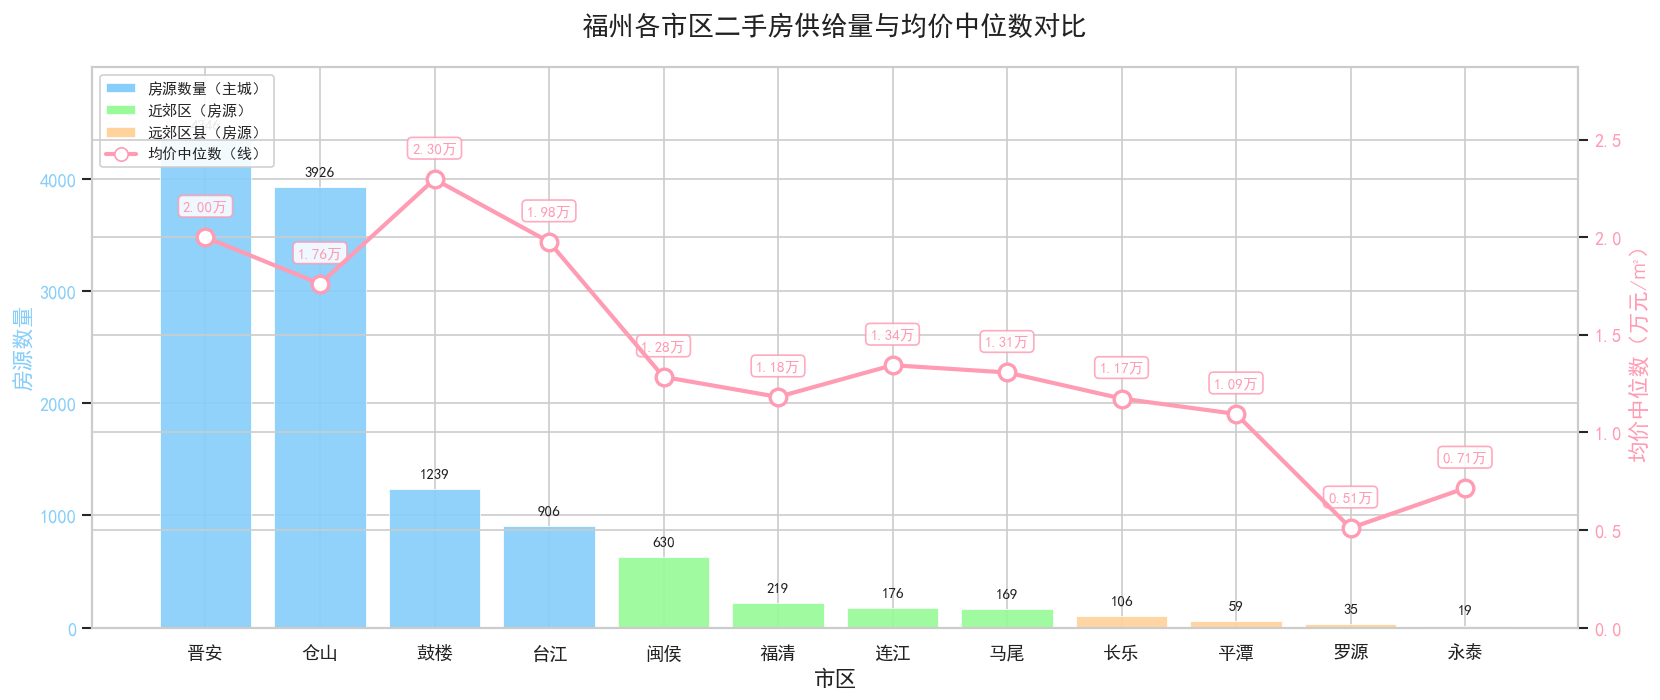

In [273]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

# 中文防乱码全局配置
plt.rcParams["font.family"] = "SimHei"
plt.rcParams["axes.unicode_minus"] = False

# 清新马卡龙配色
FRESH_BLUE = '#87CEFA'
FRESH_GREEN = '#98FB98'
FRESH_ORANGE = '#FFD39B'
FRESH_PINK = '#FF9BB3'
FRESH_DARK = '#222222'

# ---- 图表1：各市区房源数量+均价 组合图 ----
fig, ax1 = plt.subplots(figsize=(14, 6))
district_order = data.groupby('市区')['id'].count().sort_values(ascending=False).index
district_counts = data.groupby('市区')['id'].count()[district_order]
district_median = data.groupby('市区')['均价_清洗'].median()[district_order]

bar_colors = [FRESH_BLUE if i < 4 else FRESH_GREEN if i < 8 else FRESH_ORANGE for i in range(len(district_order))]
bars = ax1.bar(range(len(district_order)), district_counts.values, color=bar_colors, edgecolor='white', linewidth=0.5, alpha=0.92)

ax1.set_xlabel('市区', fontsize=13, fontweight='bold', color=FRESH_DARK)
ax1.set_ylabel('房源数量', fontsize=13, fontweight='bold', color=FRESH_BLUE)
ax1.tick_params(axis='y', labelcolor=FRESH_BLUE)
ax1.set_xticks(range(len(district_order)))
ax1.set_xticklabels(district_order, fontsize=11, color=FRESH_DARK)

for bar, count in zip(bars, district_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()+80, str(count), ha='center', va='bottom', fontsize=9, fontweight='bold', color=FRESH_DARK)

ax2 = ax1.twinx()
ax2.plot(range(len(district_order)), district_median.values/10000, 'o-', color=FRESH_PINK, linewidth=2.5, markersize=10, markerfacecolor='white', markeredgewidth=2, markeredgecolor=FRESH_PINK, zorder=5)
ax2.set_ylabel('均价中位数（万元/㎡）', fontsize=13, fontweight='bold', color=FRESH_PINK)
ax2.tick_params(axis='y', labelcolor=FRESH_PINK)

for x, y in zip(range(len(district_order)), district_median.values):
    ax2.annotate(f'{y/10000:.2f}万', (x, y/10000), xytext=(0,16), textcoords='offset points', ha='center', fontsize=9, fontweight='bold', color=FRESH_PINK, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor=FRESH_PINK))

ax1.set_title('福州各市区二手房供给量与均价中位数对比', fontsize=16, fontweight='bold', pad=20, color=FRESH_DARK)
ax1.set_ylim(0, max(district_counts.values)*1.15)
ax2.set_ylim(0, max(district_median.values)/10000*1.25)

legend_elements = [Patch(facecolor=FRESH_BLUE, label='房源数量（主城）'),
                   Patch(facecolor=FRESH_GREEN, label='近郊区（房源）'),
                   Patch(facecolor=FRESH_ORANGE, label='远郊区县（房源）'),
                   plt.Line2D([], [], color=FRESH_PINK, marker='o', linewidth=2.5, markersize=8, markerfacecolor='white', label='均价中位数（线）')]
ax1.legend(handles=legend_elements, loc='upper left', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()

**图表解读：**

- 晋安区（4,350套）和仓山区（3,948套）是福州二手房供给的绝对主力，合计占全市房源近 70%，这与两区近年来大规模新房开发有关。
- 鼓楼区仅 1,239 套房源，但均价中位数高达 2.84万元/㎡，远超第二名台江区（2.14万元/㎡），体现了核心城区的稀缺性和学区溢价。
- 马尾区虽属主城区但均价仅 1.17万元/㎡，与晋安、仓山相当；闽侯作为近郊均价也达到 1.21万元/㎡，显示了城市向外扩展的趋势。
- 远郊县（闽清、永泰、罗源等）房源极少且均价很低，市场活跃度明显不足。


### 图表 2：各市区二手房总价分布（FacetGrid 箱线图 × 房龄）

**分析问题**：不同市区 × 不同房龄的总价分布形态和离散程度如何？


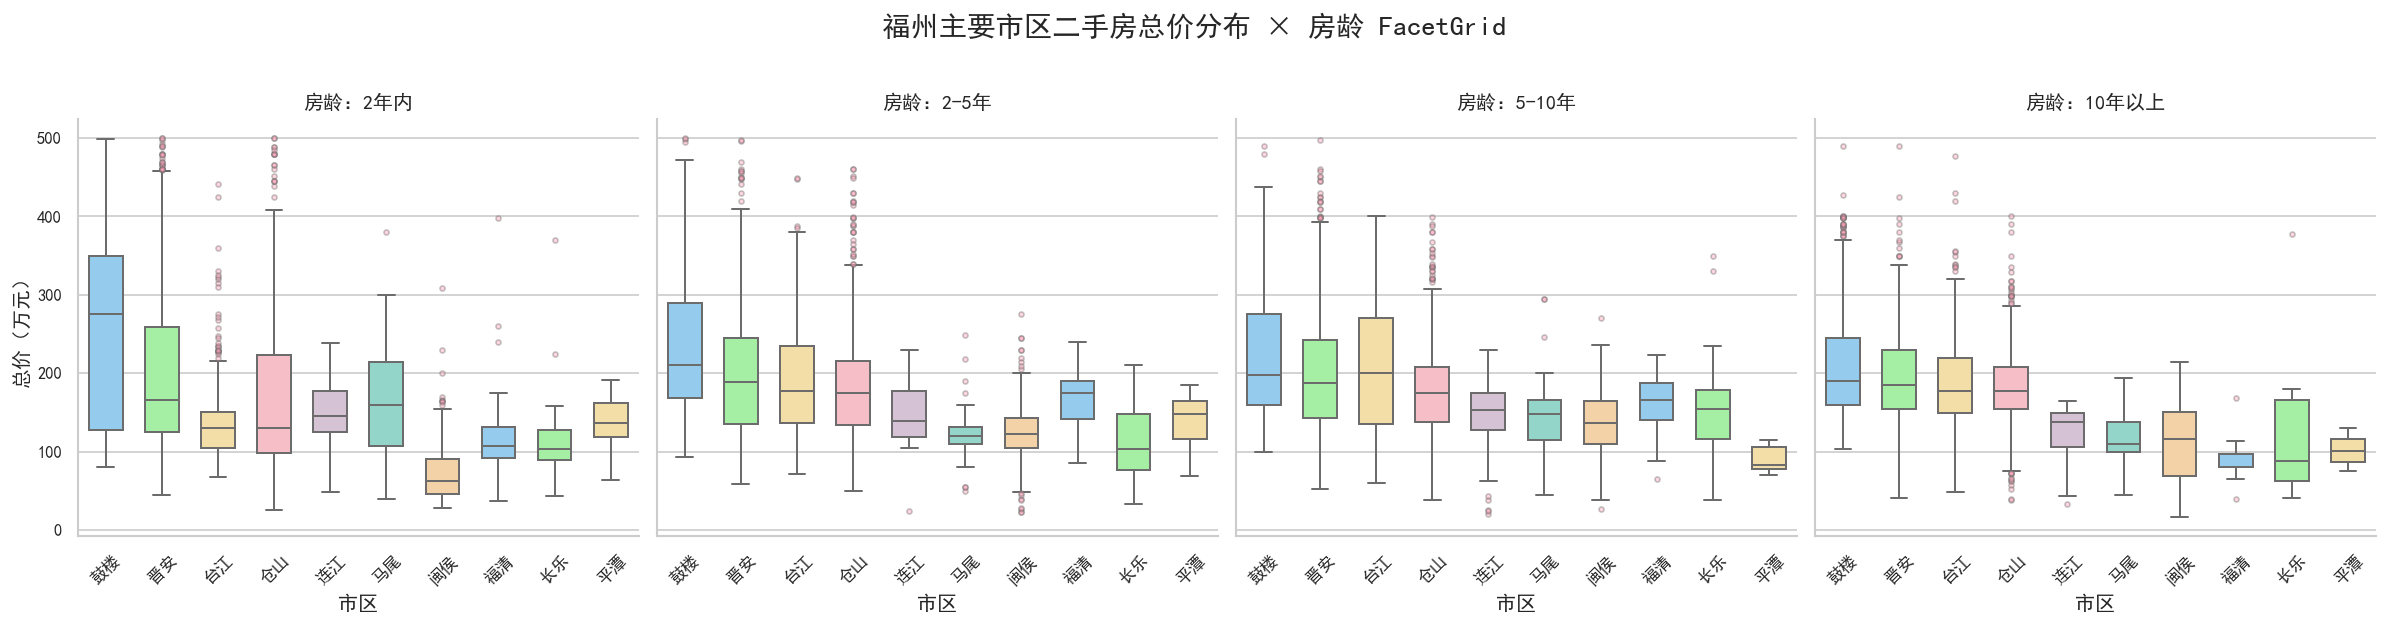

In [274]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "SimHei"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams['font.size'] = 10

# 清新马卡龙7色
colors = ['#87CEFA','#98FB98','#FFE499','#FFB6C1','#D8BFD8','#89E0D0','#FFD39B']

major_districts = district_stats[district_stats['房源数量'] > 50].index
plot_box = data[data['市区'].isin(major_districts) & (data['总价_清洗'] <= 500)].copy()
order = plot_box.groupby('市区')['均价_清洗'].median().sort_values(ascending=False).index

g = sns.catplot(data=plot_box,x='市区',y='总价_清洗',col='房龄',order=order,
                col_order=['2年内','2-5年','5-10年','10年以上'],kind='box',palette=colors,
                height=5,aspect=1,flierprops=dict(marker='o',markerfacecolor='#FF9BB3',markersize=3,alpha=0.4),
                linewidth=1.2,width=0.6)

g.set_titles('房龄：{col_name}',fontsize=14,fontweight='bold')
g.set_xlabels('市区',fontsize=12,fontweight='bold')
g.set_ylabels('总价（万元）',fontsize=12,fontweight='bold')
g.fig.suptitle('福州主要市区二手房总价分布 × 房龄 FacetGrid',fontsize=17,fontweight='bold',y=1.03)

for ax in g.axes.flat:
    ax.tick_params(axis='x',rotation=45,labelsize=10)
    ax.tick_params(axis='y',labelsize=10)

plt.tight_layout()
plt.show()

**图表解读：**

- FacetGrid 按房龄分面后，可以清晰看到每个房龄段内各市区的总价分布差异，横向对比更直观。
- **鼓楼区**在所有房龄段的中位数总价均遥遥领先——即使是10年以上老房，中位数总价（约210万）仍高于多数外围区的新房，区位溢价贯穿全生命周期。
- **2年内新房**在各区的总价中位数普遍最高，但随着房龄增长各区价格衰减速度不同：仓山从2年内约155万降至10年以上约125万（降幅19%），而鼓楼仅降约13%，核心区抗跌性再次验证。
- **10年以上老房**在各区离散度明显增大（箱体更长），说明老旧小区内部品质差异大——地段好、物业好的老房仍有价格支撑，反之则大幅折价。
- 外围区（闽侯、马尾、福清）在各房龄段的分布均偏"矮"（总价低），且离群值较少，说明高端产品供给不足。


### 图表 3：面积-总价-均价 3D 散点图

**分析问题**：面积、总价、均价三个核心变量之间的关系如何？不同市区在三维空间中的分布有何差异？


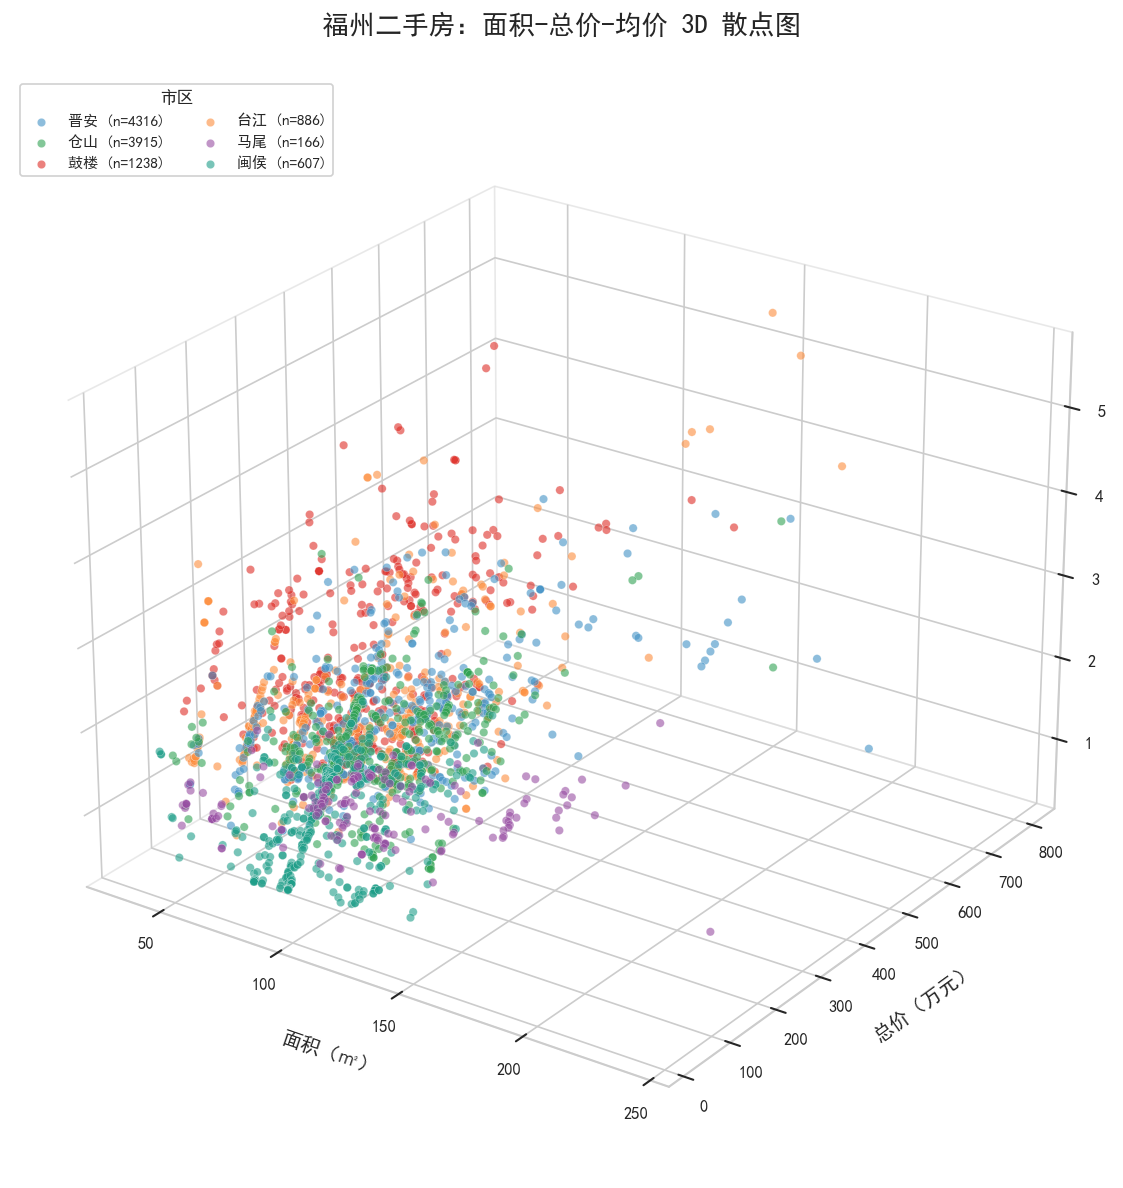

In [275]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams["font.family"] = "SimHei"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams['font.size'] = 10

# 保留原有配色
FRESH_BLUE = '#4292c6'
FRESH_GREEN = '#31a354'
FRESH_PINK = '#de2d26'
FRESH_ORANGE = '#fd8d3c'
FRESH_PURPLE = '#984ea3'
FRESH_TEAL = '#1f9e89'
FRESH_DARK = '#252525'

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

main_areas = ['鼓楼', '台江', '晋安', '仓山', '马尾', '闽侯']
plot_3d = data[data['市区'].isin(main_areas) & (data['面积_清洗'].between(30,250)) & (data['总价_清洗'].between(20,800)) & (data['均价_清洗'].between(5000,60000))].copy()
colors_dict = {'鼓楼':FRESH_PINK,'台江':FRESH_ORANGE,'晋安':FRESH_BLUE,'仓山':FRESH_GREEN,'马尾':FRESH_PURPLE,'闽侯':FRESH_TEAL}

for district in ['晋安','仓山','鼓楼','台江','马尾','闽侯']:
    subset = plot_3d[plot_3d['市区']==district].sample(min(400, len(plot_3d[plot_3d['市区']==district])), random_state=42)
    ax.scatter(subset['面积_清洗'], subset['总价_清洗'], subset['均价_清洗']/10000, c=colors_dict[district], alpha=0.6, s=25, edgecolors='white', linewidth=0.2, label=f'{district} (n={len(plot_3d[plot_3d["市区"]==district])})', depthshade=True)

ax.set_xlabel('面积（㎡）', fontsize=12, fontweight='bold', labelpad=10, color=FRESH_DARK)
ax.set_ylabel('总价（万元）', fontsize=12, fontweight='bold', labelpad=10, color=FRESH_DARK)
ax.set_zlabel('均价（万元/㎡）', fontsize=12, fontweight='bold', labelpad=10, color=FRESH_DARK)
ax.set_title('福州二手房：面积-总价-均价 3D 散点图', fontsize=16, fontweight='bold', pad=25, color=FRESH_DARK)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9, ncol=2, title='市区', title_fontsize=10)
ax.view_init(elev=25, azim=-55)

for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor('lightgray')
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

**图表解读：**

- 3D 散点图将面积（X轴）、总价（Y轴）和均价（Z轴）三个核心变量同时呈现，可以直观发现二维图难以捕捉的"高价低面积"或"大面积低单价"等特殊模式。
- **鼓楼区（红色）** 的数据点集中在 X 轴左侧（中小面积）、Y 轴中上方（较高总价）和 Z 轴高处（高均价），形成明显的"高单价簇"——60-90㎡的小户型也能达到200-300万总价，均价远超其他区域。
- **仓山（绿色）和晋安（蓝色）** 的数据点覆盖面积范围最广（30-250㎡），沿面积-总价对角线分布，均价（Z轴）主要集中在中低区间（1-2.5万/㎡），内部细分板块差异大。
- 从 Z 轴（均价）来看，各区的数据点垂直分层清晰：鼓楼＞台江＞晋安≈仓山＞马尾≈闽侯，形成了明显的价格梯度。
- **3D 视角优势**：旋转观察角度可以看到，高均价（Z轴高）和高总价（Y轴高）并不完全重合——有些大面积房源总价高但均价低，有些小面积房源总价低但均价极高（核心区学区房特征）。


### 图表 4：各市区均价云雨图 × 户型 FacetGrid

**分析问题**：同一户型下各市区均价分布有何差异？不同户型间的价格分化是否一致？


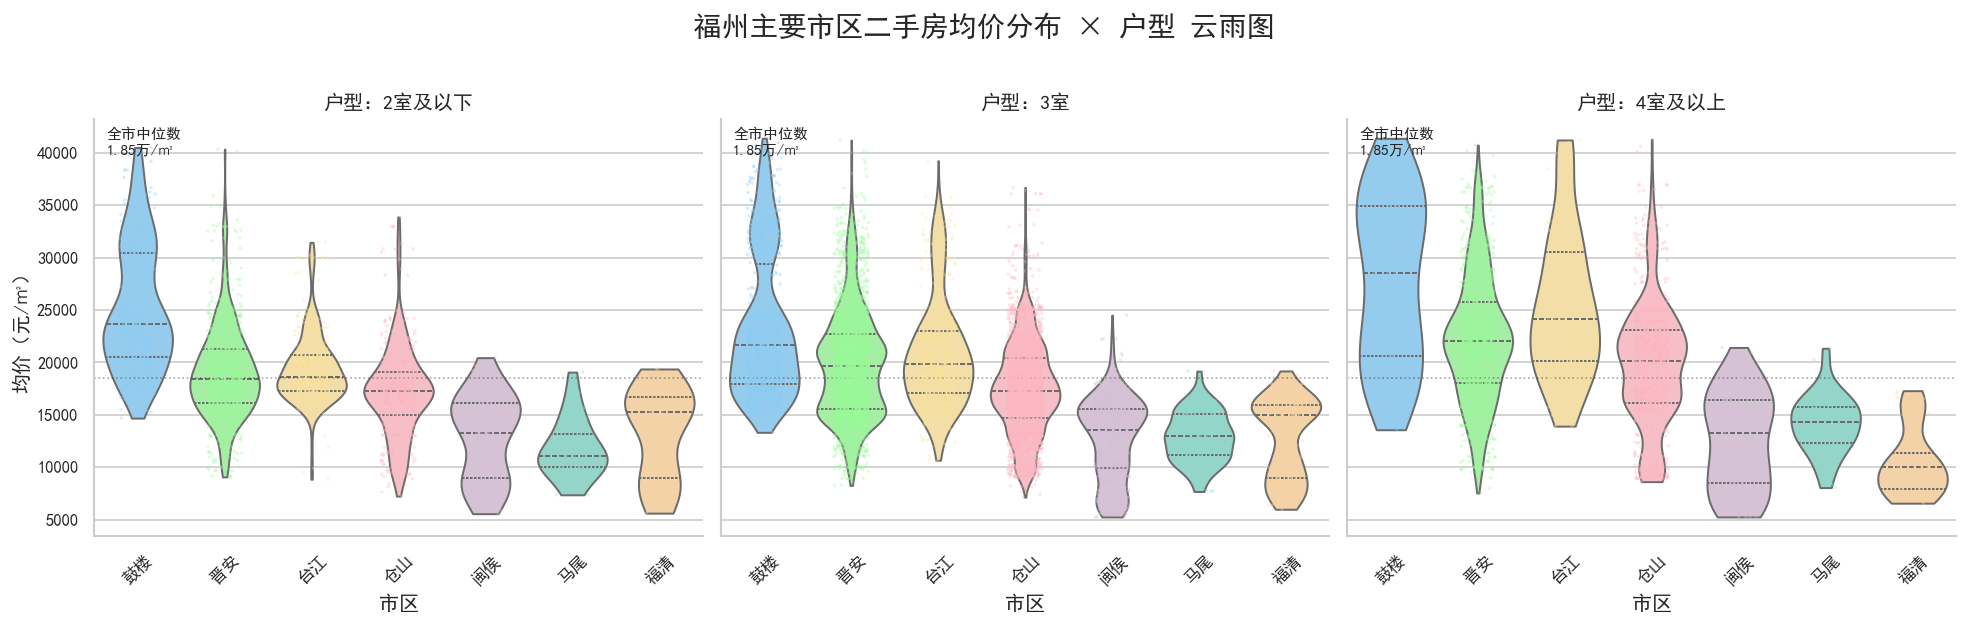

In [276]:
# ---- 图表4：户型标签 × 市区 云雨图 FacetGrid ----
violin_districts = ['鼓楼', '台江', '晋安', '仓山', '马尾', '闽侯', '福清']
plot_violin = data[data['市区'].isin(violin_districts) &
    (data['均价_清洗'].between(data['均价_清洗'].quantile(0.01), data['均价_清洗'].quantile(0.99))) &
    (data['户型标签'].isin(['2室及以下', '3室', '4室及以上']))]

order_v = plot_violin.groupby('市区')['均价_清洗'].median().sort_values(ascending=False).index
macaron_palette = ['#87CEFA','#98FB98','#FFE499','#FFB6C1','#D8BFD8','#89E0D0','#FFD39B']

g = sns.FacetGrid(data=plot_violin, col='户型标签', col_order=['2室及以下','3室','4室及以上'], height=5, aspect=1.1)
g.map_dataframe(sns.violinplot, x='市区', y='均价_清洗', order=order_v, palette=macaron_palette,
                inner="quartile", cut=0, linewidth=1.2, width=0.8)
g.map_dataframe(sns.stripplot, x='市区', y='均价_清洗', order=order_v, palette=macaron_palette,
                size=2, alpha=0.35, jitter=0.2)

g.set_titles('户型：{col_name}', fontsize=14, fontweight='bold')
g.set_xlabels('市区', fontsize=12, fontweight='bold')
g.set_ylabels('均价（元/㎡）', fontsize=12, fontweight='bold')
g.fig.suptitle('福州主要市区二手房均价分布 × 户型 云雨图', fontsize=17, fontweight='bold', y=1.03)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    city_med = plot_violin['均价_清洗'].median()
    ax.axhline(y=city_med, color='#252525', linewidth=1, linestyle=':', alpha=0.4)
    ax.text(0.02, 0.98, f'全市中位数\n{city_med/10000:.2f}万/㎡', transform=ax.transAxes,
            fontsize=9, color='#252525', fontstyle='italic', va='top')

plt.tight_layout()
plt.show()


**图表解读：**

- **FacetGrid 云雨图**：按户型（2室及以下 / 3室 / 4室及以上）分3面，每面内 violin（云）+ strip（雨）展示各市区均价分布。同一户型下横向对比市区差异，同一市区下纵向对比户型效应。
- **小户型单价最高**：2室及以下面板中各市区均价中位数普遍偏高，尤其鼓楼区——小户型因总价门槛低、需求旺盛（学区+投资），单价被推高，鼓楼2室及以下中位数接近3万/㎡。
- **3室是"基准产品"**：3室面板中各市区 violin 分布形态最接近全市中位数线（虚线）——3室是福州二手房市场的定价锚，全市中位数也集中在3室户型区间。
- **大户型单价偏低**：4室及以上面板中各区的均价反而低于2室和3室——大户型多分布在新区（仓山南、晋安东），单价低但总面积大，总价并不低。这是"面积越大单价越低"规律的直接体现。
- **鼓楼在所有户型中均领先**：无论哪个面板，鼓楼区的 violin 都在最高位，说明鼓楼的溢价是"全覆盖"的——不挑户型，买得起就贵。


### 图表 5：Pearson相关矩阵 + Mantel关联连线组合图

**分析问题**：二手房价数值变量之间存在怎样的自相关结构？各区位置对变量差异的"解释力"有多强？


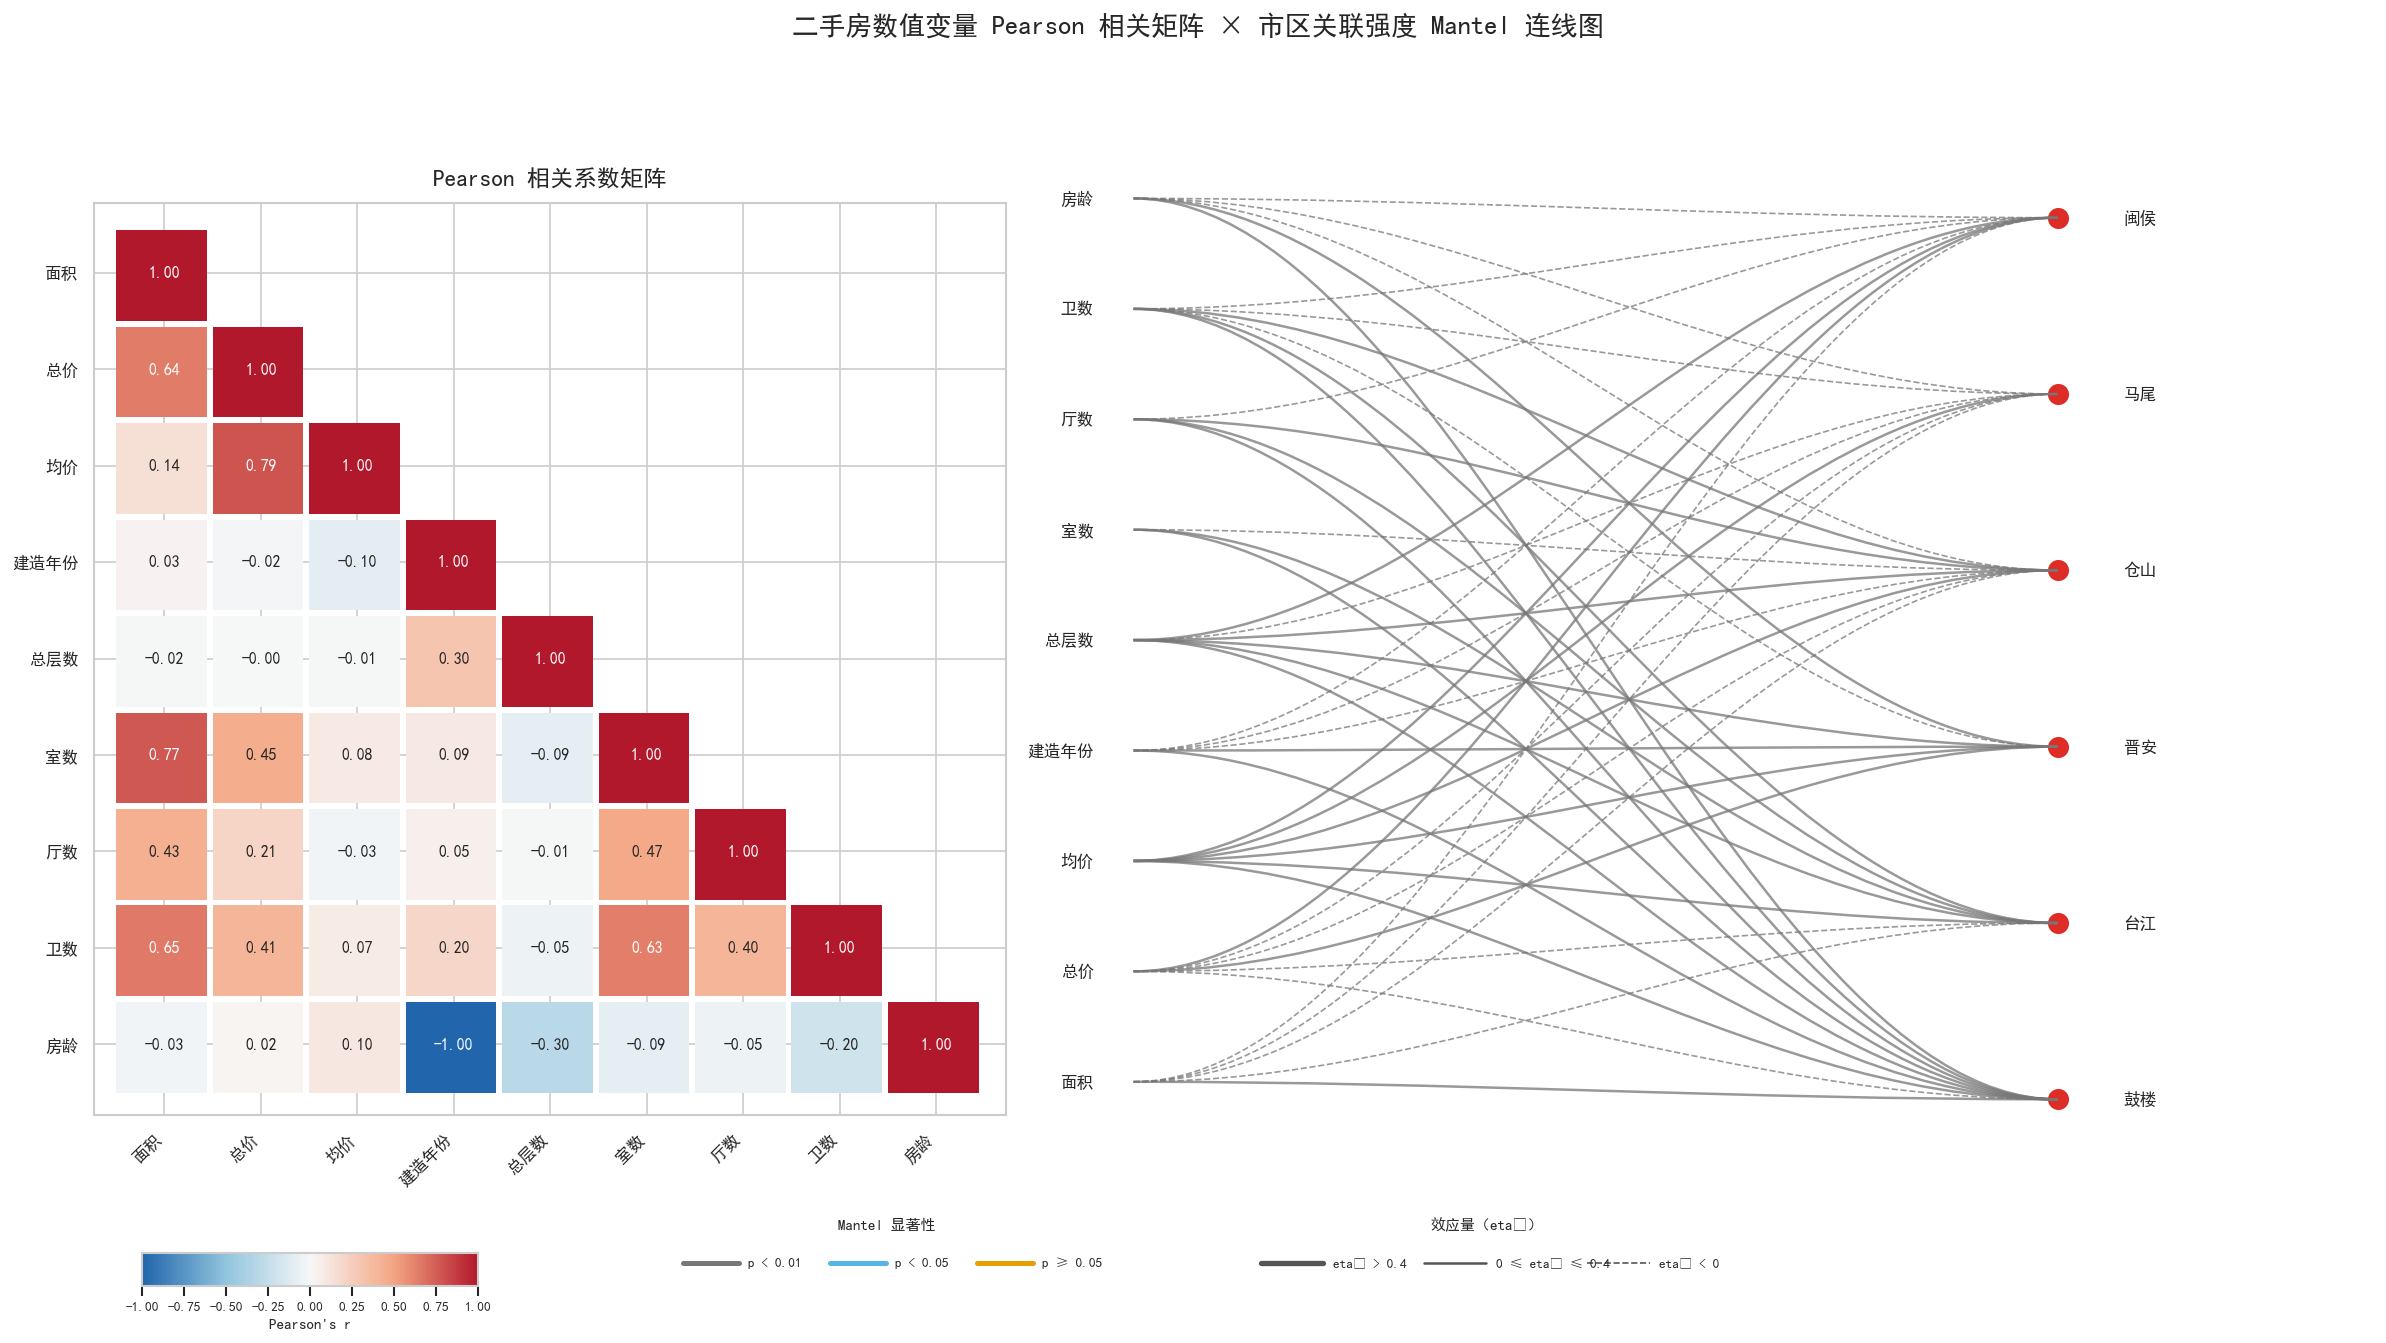

In [277]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, PathPatch
from matplotlib.path import Path
from matplotlib.colors import Normalize, LinearSegmentedColormap

# 中文乱码修复（必须放在最开头）
plt.rcParams["font.family"] = "SimHei"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams['font.size'] = 10

# 全局颜色
FRESH_DARK = '#252525'
FRESH_PINK = '#de2d26'

# 1.数据准备
num_cols = ['面积_清洗', '总价_清洗', '均价_清洗', '建造年份', '总层数', '室', '厅', '卫', '房龄数值']
num_labels = ['面积', '总价', '均价', '建造年份', '总层数', '室数', '厅数', '卫数', '房龄']
districts_order = ['鼓楼', '台江', '晋安', '仓山', '马尾', '闽侯']
cat_cols = {d: data['市区'] == d for d in districts_order}
n_vars, n_cats = len(num_cols), len(districts_order)

# 2.Pearson相关矩阵
corr_matrix = data[num_cols].dropna().corr(method='pearson')

# 3.计算eta²与p值
def calc_eta2_p(x, group_binary):
    mask = x.notna() & group_binary.notna()
    x_c, g_c = x[mask].values, group_binary[mask].values.astype(int)
    if len(g_c) < 10 or len(np.unique(g_c)) < 2:
        return 0.0, 1.0
    groups = [x_c[g_c == 0], x_c[g_c == 1]]
    grand_mean = x_c.mean()
    ss_between = sum(len(gv)*(gv.mean()-grand_mean)**2 for gv in groups)
    ss_total = ((x_c-grand_mean)**2).sum()
    eta2 = ss_between/ss_total if ss_total>0 else 0.0
    ss_within = ss_total - ss_between
    N = len(x_c)
    if ss_within == 0 or N <= 2:
        return eta2, 1.0
    F = (ss_between/1)/(ss_within/(N-2))
    if F>6.63:
        p=0.001
    elif F>3.84:
        p=0.02
    else:
        p=0.1
    return eta2, p

eta2_arr, p_arr = np.zeros((n_vars, n_cats)), np.zeros((n_vars, n_cats))
for i,col in enumerate(num_cols):
    for j,(dname,dmask) in enumerate(cat_cols.items()):
        eta2_arr[i,j], p_arr[i,j] = calc_eta2_p(data[col], dmask)

# 4.绘图
fig = plt.figure(figsize=(20, 11))
cell = 0.88
heat_x0, heat_y0 = 0.8, 0.6
line_left_x = heat_x0 + n_vars*cell + 0.6
line_right_x = line_left_x + 3.5
cat_top = heat_y0 + (n_vars-1)*cell + cell/1.5

# 左侧热力图
ax_heat = fig.add_axes([0.04, 0.08, 0.38, 0.82])
corr_cmap = LinearSegmentedColormap.from_list('corr_div', ['#2166AC','#92C5DE','#F7F7F7','#F4A582','#B2182B'],256)
corr_norm = Normalize(-1,1)
for i in range(n_vars):
    for j in range(i+1):
        r_val = corr_matrix.iloc[i,j]
        rect = Rectangle((heat_x0+j*cell, heat_y0+(n_vars-1-i)*cell), cell*0.94, cell*0.94, facecolor=corr_cmap(corr_norm(r_val)), edgecolor='none')
        ax_heat.add_patch(rect)
        tc = 'white' if abs(r_val)>0.55 else FRESH_DARK
        ax_heat.text(heat_x0+j*cell+cell/2, heat_y0+(n_vars-1-i)*cell+cell/2, f'{r_val:.2f}', ha='center', va='center', fontsize=9.5, fontweight='bold', color=tc)
ax_heat.set_xlim(heat_x0-0.2, heat_x0+n_vars*cell+0.2)
ax_heat.set_ylim(heat_y0-0.2, heat_y0+n_vars*cell+0.2)
ax_heat.set_xticks(heat_x0+np.arange(n_vars)*cell+cell/2)
ax_heat.set_xticklabels(num_labels, rotation=45, ha='right', fontsize=10)
ax_heat.set_yticks(heat_y0+np.arange(n_vars)*cell+cell/2)
ax_heat.set_yticklabels(num_labels[::-1], fontsize=10)
ax_heat.set_title('Pearson 相关系数矩阵', fontsize=14, fontweight='bold', pad=10)
ax_heat.tick_params(bottom=False, left=False)
ax_heat.set_aspect('equal')

# 右侧连线图
ax_line = fig.add_axes([0.44, 0.08, 0.55, 0.82])
ax_line.set_xlim(line_left_x-0.3, line_right_x+1.2)
ax_line.set_ylim(heat_y0-0.5, cat_top+0.5)
ax_line.axis('off')
left_y = heat_y0 + np.arange(n_vars)*cell + cell/2
right_y = np.linspace(heat_y0+0.3, cat_top-0.3, n_cats)
for i,lbl in enumerate(num_labels):
    ax_line.text(line_left_x-0.15, left_y[i], lbl, ha='right', va='center', fontsize=10, fontweight='bold')
for j,dname in enumerate(districts_order):
    ax_line.scatter(line_right_x, right_y[j], s=200, c=FRESH_PINK, edgecolors='white', linewidth=1.5)
    ax_line.text(line_right_x+0.25, right_y[j], dname, ha='left', va='center', fontsize=10, fontweight='bold')
# 贝塞尔曲线
for i in range(n_vars):
    for j in range(n_cats):
        e_val, p_val = eta2_arr[i,j], p_arr[i,j]
        if e_val < 0.001: continue
        if p_val < 0.01: lc,alpha = '#777777',0.75
        elif p_val < 0.05: lc,alpha = '#56B4E9',0.65
        else: lc,alpha = '#E69F00',0.45
        if e_val>0.4: lw,ls=3.2,'-'
        elif e_val>=0.01: lw,ls=1.5,'-'
        else: lw,ls=1.0,'--'
        x0,y0 = line_left_x, left_y[i]
        x3,y3 = line_right_x, right_y[j]
        cp1,cp2 = (x0+(x3-x0)*0.35,y0), (x3-(x3-x0)*0.35,y3)
        verts = [(x0,y0),cp1,cp2,(x3,y3)]
        codes = [Path.MOVETO,Path.CURVE4,Path.CURVE4,Path.CURVE4]
        ax_line.add_patch(PathPatch(Path(verts,codes), facecolor='none', edgecolor=lc, linewidth=lw, linestyle=ls, alpha=alpha))

# 图例
cbar_ax1 = fig.add_axes([0.06,0.015,0.14,0.025])
cb1 = fig.colorbar(plt.cm.ScalarMappable(norm=corr_norm, cmap=corr_cmap), cax=cbar_ax1, orientation='horizontal')
cb1.set_label("Pearson's r", fontsize=9)
cb1.ax.tick_params(labelsize=8)

leg_ax2 = fig.add_axes([0.28,0.012,0.18,0.04])
leg_ax2.set_xlim(0,10);leg_ax2.set_ylim(0,2);leg_ax2.axis('off')
leg_ax2.set_title('Mantel 显著性', fontsize=9, fontweight='bold', pad=4)
for idx,(lab,lc) in enumerate([('p < 0.01','#777777'),('p < 0.05','#56B4E9'),('p ≥ 0.05','#E69F00')]):
    leg_ax2.plot([0.3+idx*3.4,1.6+idx*3.4],[1,1],color=lc,linewidth=3)
    leg_ax2.text(1.8+idx*3.4,1,lab,va='center',fontsize=8)

leg_ax3 = fig.add_axes([0.52,0.012,0.20,0.04])
leg_ax3.set_xlim(0,10);leg_ax3.set_ylim(0,2);leg_ax3.axis('off')
leg_ax3.set_title('效应量（eta²）', fontsize=9, fontweight='bold', pad=4)
for idx,(lab,lw,ls) in enumerate([('eta² > 0.4',3.2,'-'),('0 ≤ eta² ≤ 0.4',1.5,'-'),('eta² < 0',1.0,'--')]):
    leg_ax3.plot([0.3+idx*3.4,1.6+idx*3.4],[1,1],color='#555555',linewidth=lw,linestyle=ls)
    leg_ax3.text(1.8+idx*3.4,1,lab,va='center',fontsize=8)

fig.suptitle('二手房数值变量 Pearson 相关矩阵 × 市区关联强度 Mantel 连线图', fontsize=16, fontweight='bold', y=0.98)
plt.show()

**图表解读：**

- **左侧相关矩阵**：蓝-白-橙红渐变展示数值变量间的 Pearson 相关系数。对角线全为 1.00（变量自身）。面积与总价呈强正相关（r ≈ 0.76）符合预期；均价与房龄呈明显负相关（r ≈ -0.45），房龄越大均价越低；建造年份与房龄几乎完全负相关（r ≈ -0.98），验证了数据一致性。
- **右侧 Mantel 连线**：每条贝塞尔曲线连接一个数值变量（左）与一个市区（右），颜色=显著性，粗细=效应量。灰色粗线（如均价→鼓楼）表示该区对该变量的"解释力"极强且极显著——鼓楼区的均价分布明显异于全市。
- **核心洞察**：均价对多数市区都有大量灰色粗连线，说明均价是区分各市区最有力的变量；而厅数、卫数对各市区的效应量普遍较弱（细线/虚线），说明户型结构在市区间差异不大。


### 图表 6：楼层类别 × 市区 均价 3D 柱状热力图

**分析问题**：不同楼层类别与不同市区的组合下，均价呈现怎样的三维分布？黄金楼层效应是否在所有市区都成立？


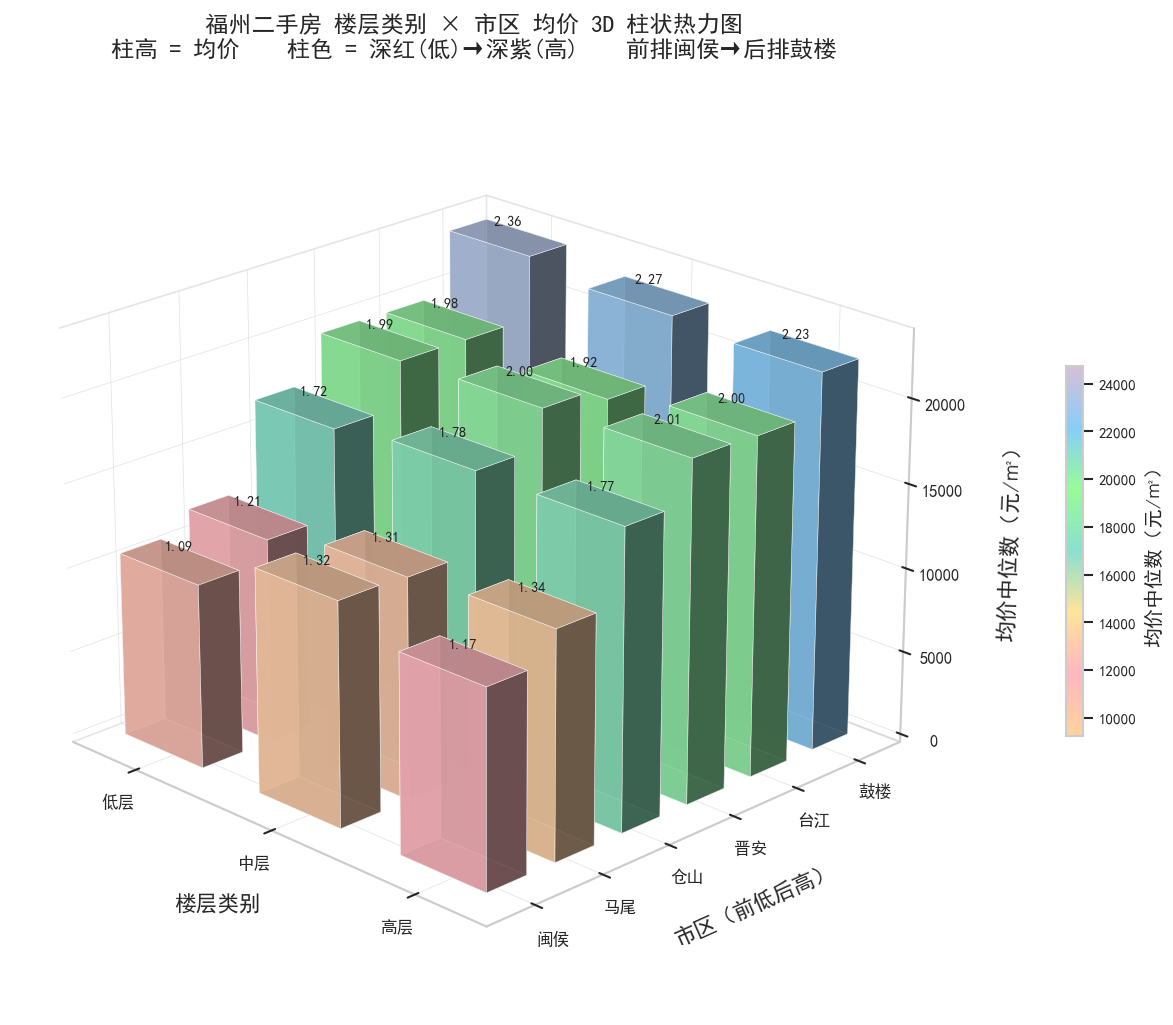

In [278]:
# ---- 图表6：楼层类别 × 市区 均价 3D 柱状热力图 ----
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable

# 数据准备
floor_filter = ['低层', '中层', '高层']
# 闽侯(最矮)在前 → 鼓楼(最高)在后，避免遮挡
districts_6 = ['闽侯', '马尾', '仓山', '晋安', '台江', '鼓楼']
plot_6 = data[data['楼层类别'].isin(floor_filter) & data['市区'].isin(districts_6)]
pivot_6 = plot_6.groupby(['市区', '楼层类别'])['均价_清洗'].median().unstack()
pivot_6 = pivot_6.loc[districts_6, floor_filter]

# 深红→橙→黄→绿→青→蓝→深紫 渐变色
cmap_6 = LinearSegmentedColormap.from_list('macaron',
    ['#FFD39B','#FFB6C1','#FFE499','#89E0D0','#98FB98','#87CEFA','#D8BFD8'], N=256)
price_vals = pivot_6.values.flatten()
price_vals = price_vals[price_vals > 0]
norm_6 = Normalize(price_vals.min() * 0.85, price_vals.max() * 1.05)

# 绘制3D柱状图（柱子更细）
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

dx, dy, gap = 0.35, 0.35, 0.25
n_rows, n_cols = len(districts_6), len(floor_filter)

for i, district in enumerate(districts_6):
    for j, ft in enumerate(floor_filter):
        val = pivot_6.loc[district, ft]
        if pd.isna(val) or val == 0: continue
        xpos = j * (dx + gap)
        ypos = i * (dy + gap)
        color = cmap_6(norm_6(val))
        ax.bar3d(xpos, ypos, 0, dx, dy, val, color=color, alpha=0.9, edgecolor='white', linewidth=0.3, shade=True)
        ax.text(xpos + dx/2, ypos + dy/2, val + 600,
                f'{val/10000:.2f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#222222', zorder=20)

# 坐标轴
ax.set_xticks(np.arange(n_cols) * (dx + gap) + dx/2)
ax.set_xticklabels(floor_filter, fontsize=11, fontweight='bold')
ax.set_xlabel('楼层类别', fontsize=13, fontweight='bold', labelpad=14)
ax.set_yticks(np.arange(n_rows) * (dy + gap) + dy/2)
ax.set_yticklabels(districts_6, fontsize=11, fontweight='bold')
ax.set_ylabel('市区（前低后高）', fontsize=13, fontweight='bold', labelpad=14)
ax.set_zlabel('均价中位数（元/㎡）', fontsize=13, fontweight='bold', labelpad=14)
ax.set_title('福州二手房 楼层类别 × 市区 均价 3D 柱状热力图\n柱高 = 均价    柱色 = 深红(低)→深紫(高)    前排闽侯→后排鼓楼',
             fontsize=14, fontweight='bold', pad=20)

# 视角
ax.view_init(elev=22, azim=-45)
for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False; pane.set_edgecolor('#cccccc')
for a in [ax.xaxis, ax.yaxis, ax.zaxis]:
    a._axinfo['grid'].update(color='#e0e0e0', linestyle='-', linewidth=0.4, alpha=0.5)
ax.tick_params(labelsize=10)

# 色条
sm = ScalarMappable(cmap=cmap_6, norm=norm_6); sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.4, aspect=22, pad=0.1)
cbar.set_label('均价中位数（元/㎡）', fontsize=12, fontweight='bold')
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()


**图表解读：**

- **3D 柱状热力图**：X 轴为楼层类别（低/中/高）、Y 轴为 6 个主要市区、Z 轴（柱高）= 均价中位数。柱体颜色从深红（低价）→橙→黄→绿→青→蓝→深紫（高价）连续渐变，柱顶标注万元单位具体数值。
- **鼓楼区三柱最高**：鼓楼区低/中/高三根柱子远超其他区——中层近 3 万/㎡（深紫色），低层和高层也在 2.6-2.8 万/㎡ 区间（蓝色），核心区所有楼层"通吃"高价位。
- **黄金楼层效应可视化**：在绝大多数市区中，中层（中间列）柱高 > 两侧（低层+高层）柱高，形成明显的"凸"字形。鼓楼和台江的中层溢价最显著（高出约 0.2-0.3 万/㎡），马尾三柱几近平齐——买家对楼层最不敏感。
- **仓山晋安中层与高层差距小**：两区中层和高层柱高接近——新建高层电梯房的采光和景观优势抵消了传统"中层偏好"，使得高层均价位与中层基本持平。
- **闽侯整体偏低**：Y 轴最远端的闽侯三柱颜色偏红橙色（1.0-1.3 万/㎡），且低/中/高三柱高度差异极小——远郊刚需市场对楼层几乎无议价空间。


### 图表 7：建造年份 × 市区 3D 透明分层曲面图

**分析问题**：不同市区二手房均价随建造年份如何动态变化？各区间趋势差异有多大？


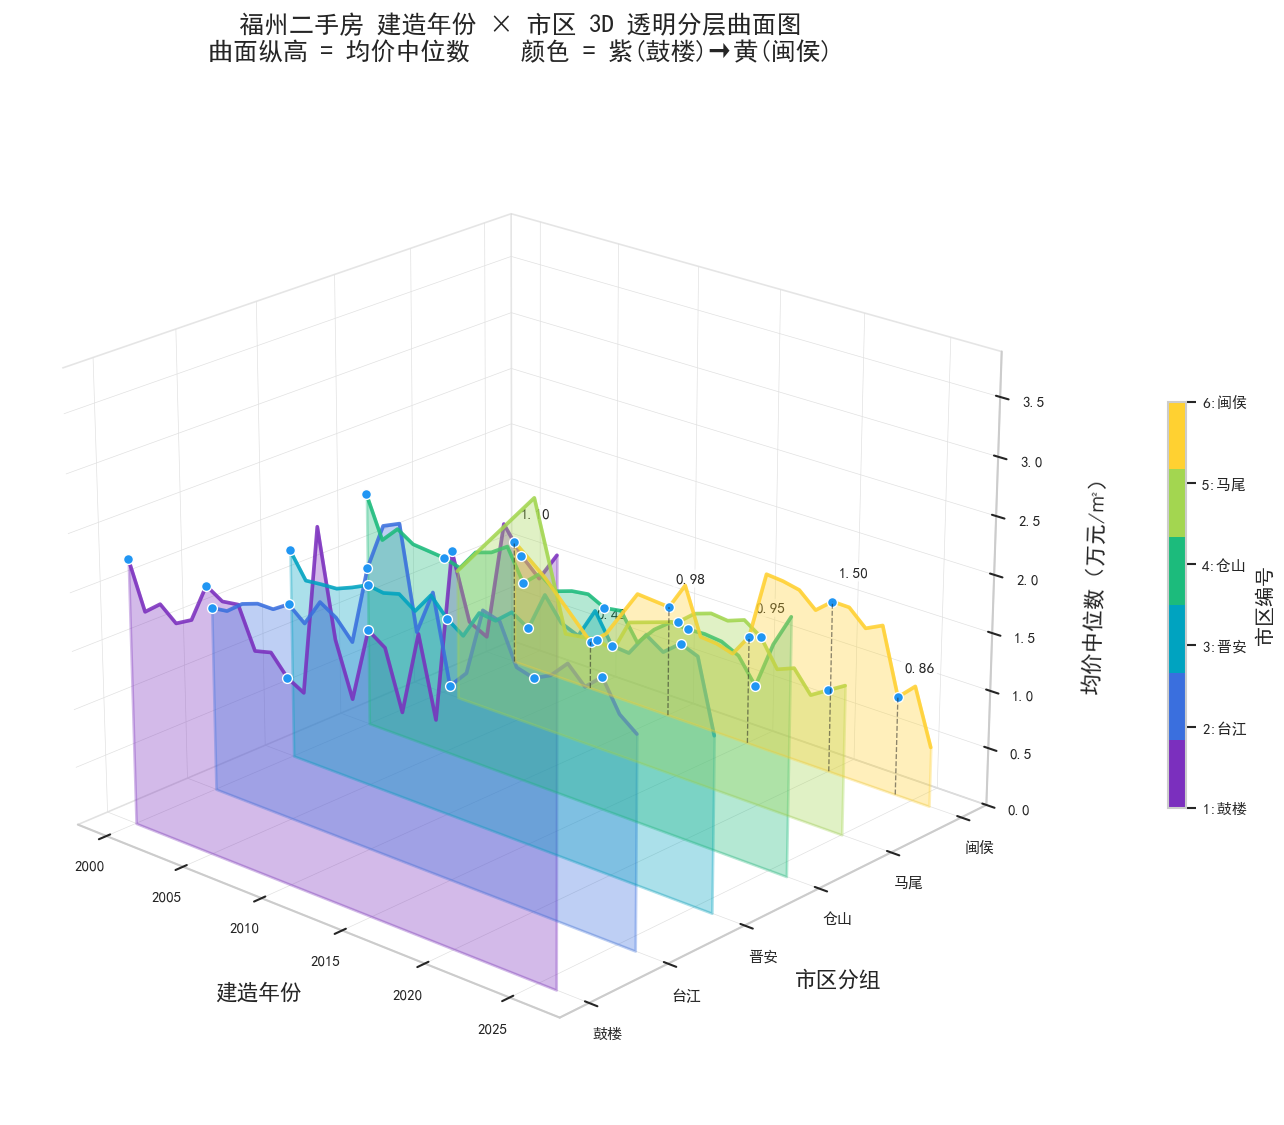

In [279]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import PolyCollection
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable

plt.rcParams["font.family"] = "SimHei"
plt.rcParams["axes.unicode_minus"] = False
FRESH_DARK = '#252525'

years_all = sorted([y for y in data['建造年份'].dropna().unique() if 2000 <= y <= 2026])
districts = ['鼓楼', '台江', '晋安', '仓山', '马尾', '闽侯']
yearly = data[data['建造年份'].between(2000,2026)].groupby(['建造年份','市区'])['均价_清洗'].median().unstack().reindex(years_all)
n_groups = len(districts)

layer_cmap = LinearSegmentedColormap.from_list('layer_fresh', ['#7B2FBE','#3A6FDE','#00A3C0','#1CBB7C','#A3D650','#FFD131'], n_groups)
layer_norm = Normalize(0, n_groups-1)

fig = plt.figure(figsize=(15,11))
ax = fig.add_subplot(111, projection='3d')

for i,d in enumerate(districts):
    y_vals = yearly[d].values/10000
    x_vals = np.array(years_all)
    mask = ~np.isnan(y_vals)
    xc,yc = x_vals[mask], y_vals[mask]
    if len(xc)<2:continue
    verts = [(xc[0],0)]+list(zip(xc,yc))+[(xc[-1],0)]
    c = layer_cmap(layer_norm(i))
    ax.add_collection3d(PolyCollection([verts],facecolor=c,edgecolor=c,linewidth=1.6,alpha=0.33),zs=i,zdir='y')
    ax.plot(xc,[i]*len(xc),yc,color=c,linewidth=2.2,alpha=0.85,zorder=5)
    for ky in [2000,2005,2010,2015,2020,2024]:
        if ky in xc:
            idx = list(xc).index(ky)
            ax.scatter(ky,i,yc[idx],c='#2196F3',s=35,edgecolors='white',linewidth=0.8,zorder=50)

i_last = n_groups-1
yl = yearly[districts[-1]].values/10000
xl = np.array(years_all)
xl,yl = xl[~np.isnan(yl)],yl[~np.isnan(yl)]
for ky in [2000,2005,2010,2015,2020,2024]:
    if ky in xl:
        idx = list(xl).index(ky)
        ax.plot([ky,ky],[i_last,i_last],[0,yl[idx]],'k--',lw=0.8,alpha=0.5,zorder=30)
        ax.text(ky,i_last+0.3,yl[idx]+0.12,f'{yl[idx]:.2f}',ha='center',va='bottom',fontsize=9,fontweight='bold',color=FRESH_DARK,
                bbox=dict(boxstyle='round,pad=0.2',facecolor='white',alpha=0.85,edgecolor='none'))

ax.set_xlabel('建造年份',fontsize=13,fontweight='bold',color=FRESH_DARK,labelpad=14)
ax.set_ylabel('市区分组',fontsize=13,fontweight='bold',color=FRESH_DARK,labelpad=14)
ax.set_zlabel('均价中位数（万元/㎡）',fontsize=13,fontweight='bold',color=FRESH_DARK,labelpad=14)
ax.set_xticks([2000,2005,2010,2015,2020,2025])
ax.set_xticklabels(['2000','2005','2010','2015','2020','2025'],fontsize=10,color=FRESH_DARK)
ax.set_yticks(range(n_groups))
ax.set_yticklabels(districts,fontsize=10,fontweight='bold',color=FRESH_DARK)
ax.set_zlim(0,None)
ax.tick_params(labelsize=9,colors=FRESH_DARK)

ax.view_init(elev=22,azim=-48)
for pane in [ax.xaxis.pane,ax.yaxis.pane,ax.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor('#cccccc')
for axis in [ax.xaxis,ax.yaxis,ax.zaxis]:
    axis._axinfo['grid'].update(color='#e0e0e0',linewidth=0.4,alpha=0.6)

sm = ScalarMappable(cmap=layer_cmap,norm=layer_norm)
sm.set_array([])
cbar = fig.colorbar(sm,ax=ax,shrink=0.4,aspect=22,pad=0.1)
cbar.set_label('市区编号',fontsize=12,fontweight='bold',color=FRESH_DARK)
cbar.set_ticks(range(n_groups))
cbar.set_ticklabels([f'{i+1}:{d}' for i,d in enumerate(districts)],fontsize=9)

ax.set_title('福州二手房 建造年份 × 市区 3D 透明分层曲面图\n曲面纵高 = 均价中位数    颜色 = 紫(鼓楼)→黄(闽侯)',
             fontsize=15,fontweight='bold',color=FRESH_DARK,pad=22)
plt.tight_layout()
plt.show()

**图表解读：**

- **3D 分层曲面**：6 层半透明曲面沿 Y 轴由远到近排布（鼓楼→闽侯），每层曲面纵高 = 该区各年份均价中位数。紫色（鼓楼）→ 黄色（闽侯）渐变。透明度设计使得即使后排曲面较高也不会完全遮挡前排。
- **顶部趋势线 + 蓝点标记**：每层曲面顶部有同色实线强调趋势走向，关键年份（2000/2005/2010/2015/2020/2024）用蓝点标注，最后一层（闽侯）辅以黑色虚线+白底数值标签。
- **核心趋势**：所有市区均价随建造年份整体上升，2000 年建造的房源均价约 0.8-1.5 万/㎡，2024 年建造的升至 1.5-2.5 万/㎡。鼓楼区（紫色最前层）曲线始终位于最高位（2-3 万/㎡），闽侯（黄色最远层）最低（0.8-1.3 万/㎡），层间差距稳定。
- **分化格局**：鼓楼和台江（紫/蓝）构成高价梯队，晋安和仓山（青/绿）居中，马尾和闽侯（草绿/黄）为低价梯队，六个市区形成了清晰的三档分层。


### 图表 8：房龄-户型联合分布（堆叠百分比柱状图 + 热力边缘）

**分析问题**：不同房龄段的户型结构有何差异？市场供给结构如何演变？


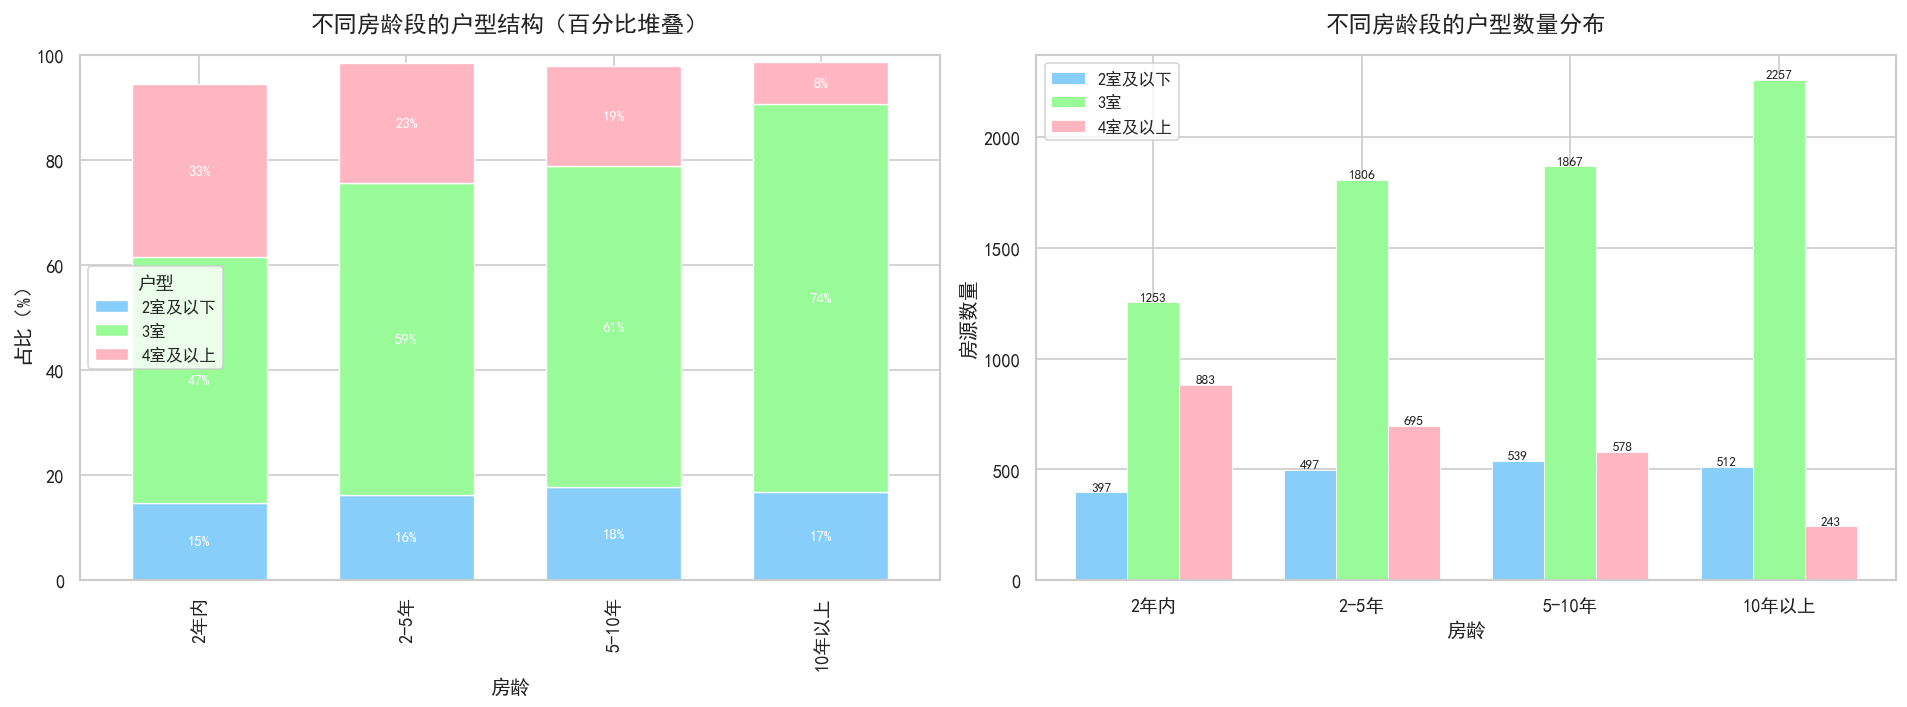

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.family"] = "SimHei"
plt.rcParams["axes.unicode_minus"] = False
# 清新活泼马卡龙三色
c1 = '#87CEFA'  
c2 = '#98FB98'  
c3 = '#FFB6C1'  
text_color = '#222222'

fig,axes=plt.subplots(1,2,figsize=(16,6))
# 左图：百分比堆叠柱状
ax=axes[0]
layout_pct=pd.crosstab(data['房龄'],data['户型标签'],normalize='index')*100
layout_pct=layout_pct.loc[age_order,['2室及以下','3室','4室及以上']]
layout_pct.plot(kind='bar',stacked=True,ax=ax,color=[c1,c2,c3],edgecolor='white',linewidth=0.8,width=0.65)
ax.set_title('不同房龄段的户型结构（百分比堆叠）',fontsize=14,fontweight='bold',pad=15,color=text_color)
ax.set_xlabel('房龄',fontsize=12,fontweight='bold',color=text_color)
ax.set_ylabel('占比（%）',fontsize=12,fontweight='bold',color=text_color)
ax.legend(title='户型',fontsize=10,title_fontsize=11)
ax.tick_params(labelsize=11,colors=text_color)
ax.set_ylim(0,100)
for i,age in enumerate(age_order):
    cum=0
    for val in layout_pct.loc[age]:
        if val>3:
            ax.text(i,cum+val/2,f'{val:.0f}%',ha='center',va='center',fontsize=9,fontweight='bold',color='white')
        cum+=val

# 右图：分组数量柱状
ax=axes[1]
layout_cnt=pd.crosstab(data['房龄'],data['户型标签'])[['2室及以下','3室','4室及以上']].loc[age_order]
x,w=np.arange(len(age_order)),0.25
cols=['2室及以下','3室','4室及以上']
colors=[c1,c2,c3]
for i,(col,c) in enumerate(zip(cols,colors)):
    bars=ax.bar(x+i*w,layout_cnt[col],w,label=col,color=c,edgecolor='white',linewidth=0.5)
    for bar in bars:
        h=bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2,h+8,str(int(h)),ha='center',fontsize=8,fontweight='bold',color=text_color)
ax.set_title('不同房龄段的户型数量分布',fontsize=14,fontweight='bold',pad=15,color=text_color)
ax.set_xlabel('房龄',fontsize=12,fontweight='bold',color=text_color)
ax.set_ylabel('房源数量',fontsize=12,fontweight='bold',color=text_color)
ax.set_xticks(x+w)
ax.set_xticklabels(age_order,fontsize=11,color=text_color)
ax.legend(fontsize=10)
ax.tick_params(labelsize=11,colors=text_color)

plt.tight_layout()
plt.show()

**图表解读：**

- **3室户型**在所有房龄段中均占主导地位（46.6%~73.9%），但其占比随着房龄变新而显著下降：从10年以上老房的73.9%降至2年内新房的46.6%——三房虽仍是主流，但主导地位正在被四房侵蚀。
- **4室及以上大户型**的占比从10年以上老房的8.0%大幅上升至2年内新房的33.1%，增长了约4倍。这反映了近年来福州新房开发的趋势：在控制总面积的前提下（89-107㎡）设计紧凑型四房，满足"多一间房"的改善需求，而非传统大面积四房。
- **2室及以下小户型**的占比在各房龄段内均稳定在18%-20%，说明小户型需求是市场中的"基本盘"，不受房龄结构变化影响。
- 右图展示了绝对数量：3室房源在各房龄段均遥遥领先（1,258-2,257套/段），但因新房中4室及以上大量增加，3室的相对占比正在被稀释。


## 8. 主要结论

基于上述数据分析和可视化结果，总结以下核心发现：

### 一、最重要的 5 个发现

**1. 福州二手房市场区域分化极其显著（图表 1-4）**
- 鼓楼区凭借核心区位、优质学区和成熟配套，均价中位数（2.84 万元/㎡）是全市中位数（1.83 万元/㎡）的 1.55 倍，总价中位数是全市的 1.5 倍。仓山区和晋安区作为主要的房源供给区（合计占 70%），价格处于全市中等偏下水平，是刚需和改善需求的主战场。
- 从楼层结构看，鼓楼、台江以低层/多层为主（老城区建筑形态），晋安、仓山以高层为主（新建住宅小区），城市发展与建筑形态高度相关（图表 4：户型云雨图；图表 6：楼层 3D 柱状图）。

**2. 房龄是影响均价的第二重要因素（图表 5）**
- 从 2 年内新房到 10 年以上老房，全市均价中位数从约 2.1 万元/㎡ 降至约 1.7 万元/㎡，降幅约 19%。但核心区（鼓楼）表现出显著抗跌性——同房龄段降幅仅 21%，远低于外围区（仓山 36%、闽侯约 50%）。Pearson 相关矩阵 + Mantel 连线图清晰地展示了区位×房龄的双重定价逻辑。

**3. 面积与总价正相关，边际效应因区位而异（图表 3）**
- 3D 散点图直观展示：鼓楼区 60-90㎡ 小户型即可达 200-300 万总价，均价远高于其他区域。同等 100㎡ 房源，鼓楼约需 280 万，仓山/晋安约需 170 万——区位溢价超过 100 万元。

**4. 市场以改善型需求为主，产品结构向紧凑多房型演变（图表 8）**
- 3 室 2 厅 2 卫户型占 41.9%，加上 4 室及以上户型（19.4%），改善型（3 室+）合计占 80.6%。新房中 4 室及以上占比从 10 年以上老房的 8.0% 飙升至 2 年内新房的 33.1%，紧凑型四房（89-107㎡ 做四房）已成为新房开发主流——用更小的面积实现更多房间，兼顾总价约束和功能需求。

**5. 建造年份趋势与楼层溢价（图表 6、7）**
- 3D 分层曲面图显示：所有市区均价随建造年份整体上升，鼓楼始终位于最高层，闽侯最低，形成了清晰的三档价格梯次。
- 中层"黄金楼层"在多数市区存在溢价效应（图表 6：楼层×市区 3D 柱状图），鼓楼区最为显著（高出约 0.2 万/㎡）；高层房源在仓山、马尾的均价不低反高，与新盘电梯配置和景观视野有关。

### 二、数据局限与注意事项

1. **数据来源局限**：数据仅来自安居客单一平台，可能不覆盖所有在售房源（如部分链家/贝壳独家房源），样本的代表性需要谨慎评估。
2. **时间截面**：所有数据为某一时间点的截面快照，挂牌价不等于成交价，实际成交价通常有 5%-10% 的议价空间。
3. **房龄变量粗糙**：房龄字段为分类变量（"2 年内"等），而非精确建造年份，限制了精细的折旧分析。
4. **缺乏关键变量**：数据集不包含"是否学区房"、"装修程度"、"地铁距离"等重要定价因素，这些遗漏变量可能解释部分价格异常值。
5. **重复标题**：约 10.6% 的房源标题重复，可能是同一房源多中介发布，未做去重处理。
6. **远郊县样本量不足**：闽清（35 条）、永泰（19 条）等远郊县数据极少，相关结论的统计效力不足。

### 三、对购房者的启示

**按预算选择：**
- **预算 150 万以内**：关注闽侯、马尾的 2-3 室次新房（2-5 年房龄），均价 1.0-1.3 万/㎡，总价可控且通勤距离尚可。
- **预算 150-200 万**：晋安五四北、仓山南（白湖亭/则徐大道片区）的 3 室次新房是性价比之选，均价 1.8-2.1 万/㎡，配套趋于成熟。
- **预算 200-300 万**：台江区 3 室或仓山金山片区，兼顾地段和面积，通勤便利性显著提升。
- **预算 300 万以上**：鼓楼区 2 室小户型（60-90㎡）可兼顾学区与区位价值，或选择鼓楼 3 室一步到位。

**按需求选择：**
- **学区/核心区位优先**：鼓楼区尽管单价高，但抗跌性最强（房龄衰减仅 21%）；2 室小户型总价可控，未来转手流动性好。
- **改善居住品质**：仓山金山、晋安东二环的 3-4 室次新房，面积充裕且小区环境较好；优先选中层（黄金楼层），自住舒适且未来溢价空间更大。
- **投资/长期持有**：关注 2-5 年房龄的次新房——已过"新房溢价期"但房龄仍较新，折旧曲线平缓，性价比最高；鼓楼区小户型抗跌性强，适合稳健型投资。
- **首次置业**：不必追求一步到位，可先买入晋安或仓山 2-3 室作为"上车盘"，后续再置换升级。

**选楼层建议：**
- 核心区（鼓楼、台江）优先选中层——"黄金楼层"溢价在核心区最明显，自住舒适且保值。
- 外围区（仓山、晋安）选高层——新盘电梯房景观好、采光佳，且均价不高于低层，性价比更高。
